# Notebook summary : Run_and_optimize_GLM_model

This notebook optimizies and Runs the GLM logistic regression model. It uses statsmodels to do this. 

In the section 1, we transform some of the phenotypes to make it easily run on the model

In the section 2, we run the model and assess it's accuracy via puesdo r^2

In section 3, we assess the models predictive power (by PRC) and compare that to using just gencode vs gtex distances



import functions+files
--

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
sns.set()
import scipy
sns.set_style("white")

import pandas as pd
import ast

import statsmodels
from sklearn.metrics import auc


#import SMS
#from SMS.GLM import *
from importlib import reload

from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import statsmodels.api as sm
import statsmodels.formula.api as smf

import/load data
--

In [7]:
data_directory='/Users/hannahjacobs/Dropbox (MIT)/GradSchool/Finucane/SMS_project/data/'

script_directory='/Users/hannahjacobs/Dropbox (MIT)/GradSchool/Finucane/SMS_project/scripts/'

plot_directory='/Users/hannahjacobs/Dropbox (MIT)/GradSchool/Finucane/SMS_project/figures/'



variants_affecting_phenotypes_within_5kb=pd.read_csv(data_directory+'all_variants_ready_for_model.tsv', sep='\t', low_memory=False)



delta_3p = variants_affecting_phenotypes_within_5kb.three_p_maxent_ref - variants_affecting_phenotypes_within_5kb.three_p_maxent_alt

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(abs_delta_3p_maxent=delta_3p.abs())

max_3p_maxent = variants_affecting_phenotypes_within_5kb[['three_p_maxent_ref', 'three_p_maxent_alt']].max(axis=1)

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(max_3p_maxent=max_3p_maxent)






In [8]:

data_directory = '/Users/hannahjacobs/MIT Dropbox/Hannah Jacobs/GradSchool/Finucane/SMS_project/data/'


variants_affecting_phenotypes_within_5kb_verfied_ss=pd.read_csv(data_directory+'variants_affecting_phenotypes_within_5kb.csv', 
                                                    low_memory=False)






Modify distances
--

*1. Log scale*

We have shown that for FM PIP>=0.95 variants, log distance varies linearily, while abs distance is exponentional.

This means that we have to transform distances to the log scale

*2. Change distance to ss*

Set all splice region variants to be 0 bp away from ss. That way there is no difference in distance prediction for ss variants, since we assume distance is not a factor once you actually get to the splice sites.


In [9]:
# Modify any remaining features for the model
#--
#Below we are saying that the min dist to splice site is 0 if it is in a ss, rather than showing where in the splice site the variants actually are.

variants_affecting_phenotypes_within_5kb.loc[variants_affecting_phenotypes_within_5kb['in_splice_region_leafcutter'] == True, 'min_dis_to_splice_site_within_cluster']=0
                                                                 
variants_affecting_phenotypes_within_5kb.loc[variants_affecting_phenotypes_within_5kb['in_ss_gencode'] == True, 'min_dis_to_splice_site_within_cluster']=0
      

                                                                    
#replace T/F w 1s and 0s                                                         
variants_affecting_phenotypes_within_5kb.replace({False: 0, True: 1}, inplace=True)
variants_affecting_phenotypes_within_5kb['intercept']=1




#log transform distance to gtex distances

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(abs_min_dist_to_a_ss_gtex=variants_affecting_phenotypes_within_5kb['min_dis_to_splice_site_within_cluster'].abs())

    
min_dis_to_splice_site_within_cluster_log=np.log(variants_affecting_phenotypes_within_5kb['abs_min_dist_to_a_ss_gtex']+1)

    
variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(log_abs_min_dist_to_a_ss_gtex=min_dis_to_splice_site_within_cluster_log)
 

#log transform distance to gencode 
min_dis_to_splice_site_within_gencode_log=np.log(variants_affecting_phenotypes_within_5kb.abs_distance_to_exon_gencode+1)

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(log_abs_min_dist_to_a_ss_gencode=min_dis_to_splice_site_within_gencode_log)
 

/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_12925/1561772605.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  variants_affecting_phenotypes_within_5kb.replace({False: 0, True: 1}, inplace=True)


Assign gene annotations
--

We learned that our model performs better when you seperate out introns and exons, so we will do that here.

1. *Ambigious annotations*

If either leafcutter or gencode calls a variant to be in an exon, then we assume it's being called as an exon because those are more likely to be functional than an alternative; say a deep intron variant. 



about ~5% are not in introns or exons: likely because the variants are outside the first and last exons. for now I am excluding these.


In [10]:
variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb[~variants_affecting_phenotypes_within_5kb.annot_info.isna()]

region=variants_affecting_phenotypes_within_5kb.annot_info.apply(lambda x: x.split('_')[1])

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(region=region)

both_splice_regions = (variants_affecting_phenotypes_within_5kb.in_splice_region_leafcutter==1) & (variants_affecting_phenotypes_within_5kb.in_ss_gencode==1)

just_leafcutter_ss = (variants_affecting_phenotypes_within_5kb.in_splice_region_leafcutter==1) & (variants_affecting_phenotypes_within_5kb.in_ss_gencode==0)

just_gencode_ss = (variants_affecting_phenotypes_within_5kb.in_splice_region_leafcutter==0) & (variants_affecting_phenotypes_within_5kb.in_ss_gencode==1)

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(both_splice_regions=both_splice_regions)
variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(just_leafcutter_ss=just_leafcutter_ss)
variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(just_gencode_ss=just_gencode_ss)




#seperate out if in intron or exon, then into the three classes of SS


in_any_intron=(variants_affecting_phenotypes_within_5kb.abs_min_dis_to_splice_site_within_cluster!=0) & (variants_affecting_phenotypes_within_5kb.region=='intron')

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(in_any_intron=in_any_intron)


in_any_exon=(variants_affecting_phenotypes_within_5kb.abs_min_dis_to_splice_site_within_cluster!=0) & (variants_affecting_phenotypes_within_5kb.region=='exon')

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(in_any_exon=in_any_exon)

introns=variants_affecting_phenotypes_within_5kb[~variants_affecting_phenotypes_within_5kb.in_any_exon]

exons=variants_affecting_phenotypes_within_5kb[variants_affecting_phenotypes_within_5kb.in_any_exon]



variants_affecting_phenotypes_within_5kb.loc[variants_affecting_phenotypes_within_5kb.just_gencode_ss==True, 'region'] = 'just_gencode_ss'
variants_affecting_phenotypes_within_5kb.loc[variants_affecting_phenotypes_within_5kb.both_splice_regions==True, 'region'] = 'both_splice_regions'
variants_affecting_phenotypes_within_5kb.loc[variants_affecting_phenotypes_within_5kb.just_leafcutter_ss==True, 'region'] = 'just_leafcutter_ss'


In [11]:
variants_affecting_phenotypes_within_5kb['distance_bin_gtex']=pd.cut(variants_affecting_phenotypes_within_5kb.abs_min_dist_to_a_ss_gtex, [-1, 30, 300, 3000, 5001])



spliceAI
--

In [ ]:
splice_AI_dir = '/Users/hannahjacobs/MIT Dropbox/Hannah Jacobs/GradSchool/Finucane/sQTL_snakemake_wf/other_models/spliceai_scores/'





whole_genome_filtered_spliceai_scores=pd.read_csv(splice_AI_dir+'whole_genome_filtered_spliceai_scores.txt.gz',
            compression='gzip', low_memory=False, skiprows=15, sep='\t', header=None,
                 names=['chrome', 'start', 'dot','ref', 'alt', 'info1','info2', 'INFO']                                 
                                            )



spliceAIscores = whole_genome_filtered_spliceai_scores

spliceAIscores.columns=['chrome', 'start', 'dot','ref', 'alt', 'info1','info2', 'INFO']  




In [16]:
DS_AG=spliceAIscores.INFO.apply(lambda x: x.split(';')[4].split('DS_AG=')[1])

DS_AL=spliceAIscores.INFO.apply(lambda x: x.split(';')[5].split('DS_AL=')[1])

DS_DG=spliceAIscores.INFO.apply(lambda x: x.split(';')[6].split('DS_DG=')[1])

DS_DL=spliceAIscores.INFO.apply(lambda x: x.split(';')[7].split('DS_DL=')[1])

spliceAIscores=spliceAIscores.assign(DS_AG=DS_AG)
spliceAIscores=spliceAIscores.assign(DS_AL=DS_AL)
spliceAIscores=spliceAIscores.assign(DS_DG=DS_DG)
spliceAIscores=spliceAIscores.assign(DS_DL=DS_DL)

DS_MAX=spliceAIscores[['DS_AG', 'DS_AL','DS_DG', 'DS_DL']].max(axis=1)

spliceAIscores=spliceAIscores.assign(DS_MAX=DS_MAX)



variant_id = spliceAIscores.chrome + '_' + spliceAIscores.start.astype('str') + '_' + spliceAIscores.ref + '_' + spliceAIscores.alt + '_b37'


spliceAIscores= spliceAIscores.assign(variant_id_hg19=variant_id)

In [19]:

variants_affecting_phenotypes_within_5kb_w_spliceAI=variants_affecting_phenotypes_within_5kb.merge(spliceAIscores[['DS_MAX','variant_id_hg19']], on='variant_id_hg19', how='left')
                                                          
                                            

In [9]:
#spliceAI_scores=variants_affecting_phenotypes_within_5kb[['variant_id','pip']].merge(spliceAIscores_merged[['DS_MAX','variant_id']], on='variant_id', how='right')


In [10]:
spliceAI_scores['is_causal']=spliceAI_scores.pip>=0.9

# Run + asssess GLM model

A logistic regression model is a generalized linear model that attempts to predict the binary outcome based on a set of features. Shown below is an example for a model with one feature:

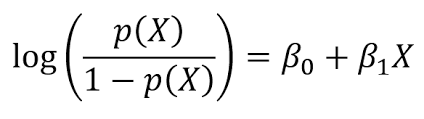

Where Bx is a coef for a given feature, and Bo is the intercept.

The model is fit by trying to find the maximulum likelihood function that fits the data. A note on likelihood functions:

*"Under this framework, a probability distribution for the target variable (class label) must be assumed and then a likelihood function defined that calculates the probability of observing the outcome given the input data and the model. This function can then be optimized to find the set of parameters that results in the largest sum likelihood over the training dataset."* 
Source:https://machinelearningmastery.com/logistic-regression-with-maximum-likelihood-estimation/. 

The model is fitting to a binominal distribution of probabilities. This is an example of the binominal distribution
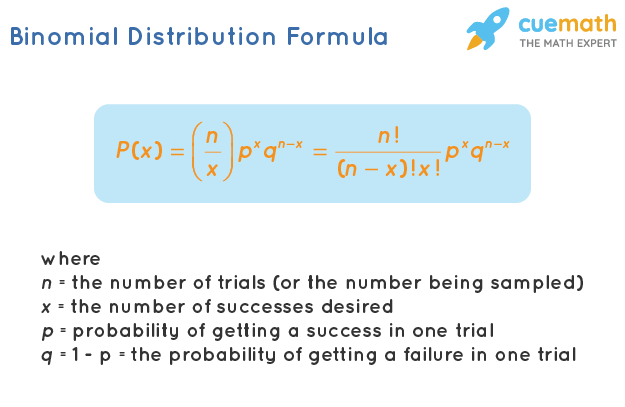

A note on intercepts:
*That dependence between the intercept and the scale of the predictors is common property of linear models. Standardizing the inputs (subtracting the average value of each feature and dividing by the standard deviation) is sometimes performed, depending on what interpretation you want the coefficients to have.*

In this case, the features are a combination of binary features and continious variables that we believe will help us predict where a variant impact splicing in GTEx


The following syntax is used for the models:

for a given *name of model*:

- model_fit_*name* : the GLM output

- train_df_*name* : the training df used in the model

- test_df_*name* : the test set 

- test_df_*name* : the model assessed across all variants (test+train+all other PIPs)

The names of the modesl correspond to the following:

- full: full SMS model 
- region: only using gene annotation info (intron, exon, splice sites)
- no_dists : full model without any distance
- gtex_dist: only using gtex_distances
- gtex_dist: only using gencode_distances
- full_but_gencode_dist: full model, but using gencode distance instead of GTEx distances



In [24]:
import SMS

Run model
--

In [25]:
#reload(SMS.GLM)
from SMS.GLM import *

Filter out the CT/AC splice sites (low maxent scores)
--

In [26]:
with open(data_directory+'list_of_ss_to_exclude.txt', 'r') as f:

    lines = f.readlines()

list_of_ss_to_exclude=[l.split('\n')[0] for l in lines]

In [30]:
variants_affecting_phenotypes_within_5kb_verfied_ss=variants_affecting_phenotypes_within_5kb_w_spliceAI[~variants_affecting_phenotypes_within_5kb_w_spliceAI.ID.isin(list_of_ss_to_exclude)]




variants_affecting_phenotypes_within_5kb_verfied_ss = variants_affecting_phenotypes_within_5kb_verfied_ss.assign(DS_MAX=variants_affecting_phenotypes_within_5kb_verfied_ss.DS_MAX.fillna(0).astype('float'))

In [31]:
import scikitplot as skplt
import scikitplot as skplt
from sklearn import metrics
from sklearn.metrics import RocCurveDisplay

run full model 
--

In [32]:
    #features
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [37]:
#variants_affecting_phenotypes_within_5kb_verfied_ss=single_variant

run model
--

In [34]:
not_ss=variants_affecting_phenotypes_within_5kb_verfied_ss.region.isin(['intron','exon'])
variants_affecting_phenotypes_within_5kb_verfied_ss=variants_affecting_phenotypes_within_5kb_verfied_ss.assign(not_ss=not_ss)


In [35]:
[model_fit_full, train_df_full, test_df_full, model_output_full]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'default_features', 'w_gtex_distances')



record single variant model
--

In [36]:

df = variants_affecting_phenotypes_within_5kb_verfied_ss
single_variant = df.sort_values( by='pip', ascending=False).drop_duplicates(subset=['variant_id'])

In [37]:
[model_fit_full_single_variant, train_df_full_single_variant, test_df_full_single_variant, model_output_full_single_variant]=SMS.GLM.run_model(single_variant, 0.9, 0.002, 'default_features', 'w_gtex_distances')


In [39]:


puesdo_r_sq_full_model=SMS.GLM.print_puesdo_r(model_fit_full.llf, SMS.GLM.null_model_given_training_set(train_df_full).llf, False, ' of full model')

                                        


the puesdo_r_sq is 0.49566949153875384 of full model


In [38]:
puesdo_r_sq_full_model=SMS.GLM.print_puesdo_r(model_fit_full_single_variant.llf, SMS.GLM.null_model_given_training_set(train_df_full_single_variant).llf, False, ' of full model, single variants')


the puesdo_r_sq is 0.5518107062120088 of full model, single variants


In [40]:
#single_variant_model=model_output_full.sort_values(by='predicted_prob_being_causal', ascending = False).drop_duplicates(subset='variant_id')

export
--

In [103]:
model_output_full=model_output_full.assign(sQTL_pip=model_output_full.pip)





suppfile_data_directory='/Users/hannahjacobs/Dropbox (MIT)/GradSchool/Finucane/splicing_variation_in_humans_2022/data/01_data/'

features = [
    'variant_id','sQTL_pip','predicted_prob_being_causal', 'DS_MAX',
    'log_abs_min_dist_to_a_ss_gtex', 'log_abs_min_dist_to_a_ss_gencode',
    'in_oRNAment', 'in_eCLIP', 'either_ESE', 'either_ESS', 'DHS_Trynka',
    'H3K27ac_PGC2','TSS_Hoffman', 'TFBS_ENCODE', 'H3K9ac_Trynka','Promoter_UCSC', 
    'H3K4me1_Trynka', 'Enhancer_Hoffman', 'Transcribed_Hoffman','gc_twenty_bp',
    'phastcons_100','max_5p_maxent', 'abs_delta_5p_maxent', 'max_3p_maxent',
    'abs_delta_3p_maxent','in_any_intron', 'in_any_exon','not_ss',
    'both_splice_regions', 'just_leafcutter_ss', 'just_gencode_ss','variant_id_hg19'
]



supplemental_data_directory='/Users/hannahjacobs/Dropbox (MIT)/GradSchool/Finucane/splicing_variation_in_humans_2022/data/01_data/supplemental_files_for_paper/'

gtex_variant_SMS_scores_for_export = model_output_full[features]




gtex_variant_SMS_scores_for_export = gtex_variant_SMS_scores_for_export.assign( max_splice_ai_score = gtex_variant_SMS_scores_for_export.DS_MAX)

gtex_variant_SMS_scores_for_export = gtex_variant_SMS_scores_for_export.assign( SMS_score_full_model = gtex_variant_SMS_scores_for_export.predicted_prob_being_causal)



gtex_variant_SMS_scores_for_export_to_supplement = gtex_variant_SMS_scores_for_export[['variant_id','variant_id_hg19','SMS_score_full_model', 'DS_MAX']]

gtex_variant_SMS_scores_for_export_to_supplement.sort_values(by='SMS_score_full_model', ascending=False).to_csv(supplemental_data_directory+'SMS_scores_all_GTEx.csv.gz',
                     compression='gzip',index=False)



files for zenodo
--

In [106]:
gtex_variant_SMS_scores_for_export.sort_values(by='SMS_score_full_model', ascending=False)
df=gtex_variant_SMS_scores_for_export.drop_duplicates()
df.to_parquet(supplemental_data_directory+'SMS_scores_all_GTEx_w_features_to_retrain.parquet'
                     )



prc curve
--

In [109]:

def get_percision_given_prc_curve(model_outputs, prc,thresholds):
    
    thresholds = list(prc.threshold)

    model_outputs['binned_threshold'] = pd.cut(model_outputs['predicted_prob_being_causal'], thresholds)

    prc['binned_threshold'] = pd.cut(prc['threshold'], thresholds)

    model_outputs=model_outputs.merge(prc, on='binned_threshold')

    return model_outputs


In [110]:
#


fit the other subset models
--

In [112]:
###### GTEx ss as distance, or no distance secondary sequence models########

[model_fit_region, train_df_region, test_df_region, model_output_region]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'annot_only', 'w_gtex_distances')



[model_fit_no_dists, train_df_no_dists, test_df_no_dists, model_output_no_dists]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'default_features', 'no_distance')



[model_fit_gtex_dist, train_df_gtex_dist, test_df_gtex_dist, model_output_gtex_dist]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'distance_only','w_gtex_distances' )
                                          


###### gencode ss as distance, primary sequence models########


[model_fit_full_but_gencode_dist, train_df_full_but_gencode_dist, test_df_full_but_gencode_dist, model_output_full_but_gencode_dist]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'default_features', 'w_gencode_distances')

[model_fit_gencode_dist, train_df_gencode_dist, test_df_gencode_dist, model_output_gencode_dist]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb_verfied_ss, 0.9, 0.002, 'distance_only', 'w_gencode_distances')


In [113]:
from matplotlib.ticker import MaxNLocator




# plots


single variant figure
--

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


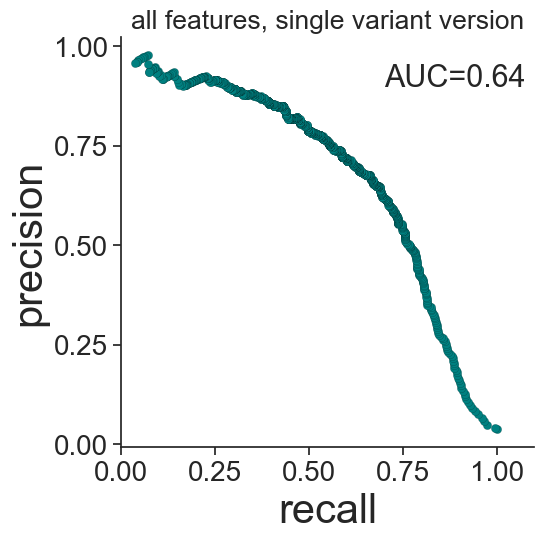

In [129]:
sns.set_style('ticks')
fig, axes = plt.subplots(1, 1, figsize=(8/1.5, 8/1.5), sharey=True)

#[model_fit_full_single_variant, train_df_full_single_variant, test_df_full_single_variant, model_output_full_single_variant]=SMS.GLM.run_model(single_variant, 0.9, 0.002, 'default_features', 'w_gtex_distances')


prc=SMS.GLM.run_prc_over_thresholds(test_df_full_single_variant, test_df_full_single_variant.is_causal, test_df_full_single_variant.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)
sns.despine()
AUC='AUC='+str(round(auc_precision_recall,2))
axes.text(0.7, 0.9, AUC, fontsize = 22)
axes.set_xlabel('recall', size=30)
axes.set_ylabel('precision', size=30)
ax=sns.scatterplot(ax=axes,data=prc, x='recall', y='precision', color='teal', linewidth=0.1, edgecolor='black')
axes.tick_params(axis='x', labelsize=20 )
axes.tick_params(axis='y', labelsize=20 )
axes.set_xlim([0,1.1])
axes.set_title('all features, single variant version', fontsize=19)
axes.xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes.yaxis.set_major_locator(MaxNLocator(nbins=5))




extended data figure: subset of features models
--

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


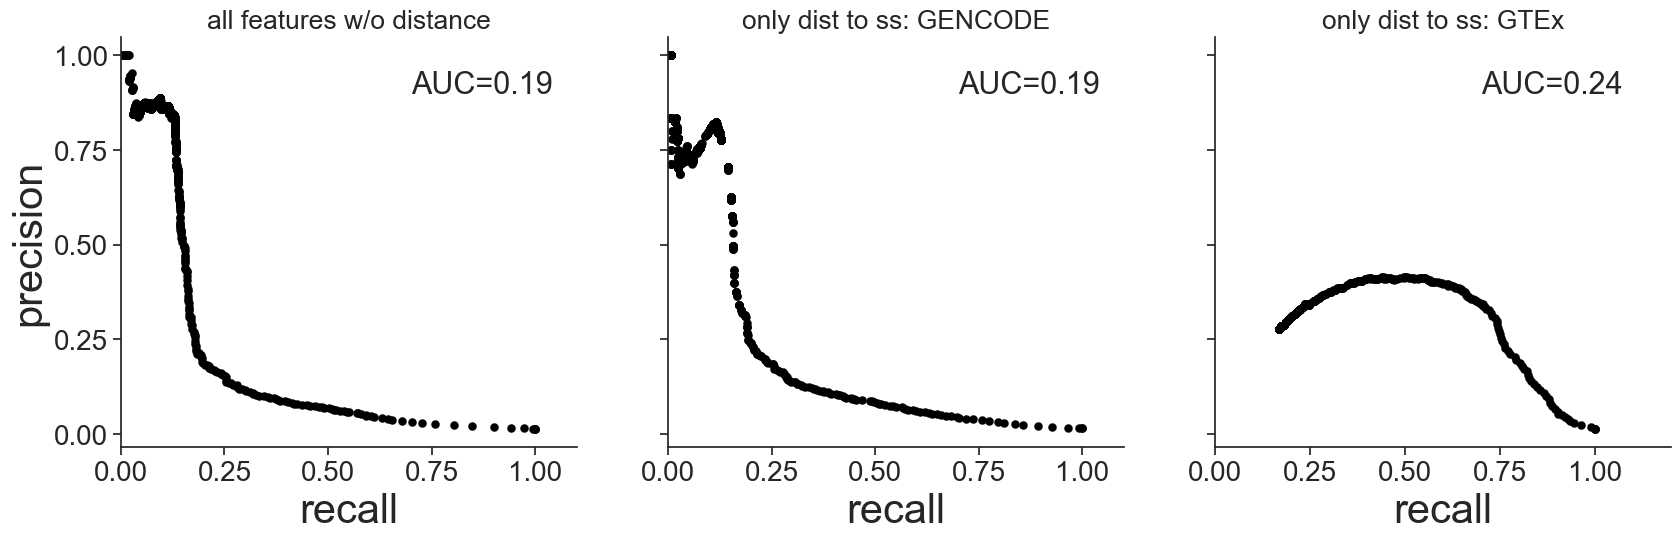

In [97]:
sns.set_style('ticks')
fig, axes = plt.subplots(1, 3, figsize=(30/1.5, 8/1.5), sharey=True)

prc=SMS.GLM.run_prc_over_thresholds(test_df_no_dists, test_df_no_dists.is_causal, test_df_no_dists.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='AUC='+str(round(auc_precision_recall,2))
axes[0].text(0.7, 0.9, AUC, fontsize = 22)
axes[0].set_xlabel('recall', size=30)
axes[0].set_ylabel('precision', size=30)
ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', color='black', linewidth=0.1, edgecolor='black')
axes[0].tick_params(axis='x', labelsize=20 )
axes[0].tick_params(axis='y', labelsize=20 )
axes[0].set_xlim([0,1.1])
axes[0].set_title('all features w/o distance', fontsize=19)
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

prc=SMS.GLM.run_prc_over_thresholds(test_df_gencode_dist, test_df_gencode_dist.is_causal, test_df_gencode_dist.predicted_prob_being_causal)
ax=sns.scatterplot(ax=axes[1],data=prc, x='recall', y='precision', color='black',linewidth=0.1, edgecolor='black')
ax.set_xlabel('recall', size=30)
axes[1].tick_params(axis='x', labelsize=20 )
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[1].text(0.7, 0.9, AUC, fontsize = 22)
axes[1].set_title('only dist to ss: GENCODE', fontsize=19)
axes[1].set_xlim([0,1.1])
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=5))



prc=SMS.GLM.run_prc_over_thresholds(test_df_gtex_dist, test_df_gtex_dist.is_causal, test_df_gtex_dist.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[2].text(0.7, 0.9, AUC, fontsize = 22)
axes[2].set_xlim([0,1.2])
ax=sns.scatterplot(ax=axes[2],data=prc, x='recall', y='precision', color='black', linewidth=0.1, edgecolor='black')
axes[2].set_xlabel('recall', size=30)
axes[2].tick_params(axis='x', labelsize=20 )
axes[2].set_title('only dist to ss: GTEx', fontsize=19)
axes[2].xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=5))


sns.despine()


In [130]:
mako_pal=sns.color_palette('mako')

In [134]:
variants_affecting_phenotypes_within_5kb_w_spliceAI['DS_MAX']=variants_affecting_phenotypes_within_5kb_w_spliceAI.DS_MAX.fillna(0).astype('float')

splice AI comparison
--

In [136]:
# Running the model with 'DS_MAX' feature and no distance consideration
[model_fit_spliceAI, train_df_spliceAI, test_df_spliceAI, model_output_spliceAI] = SMS.GLM.run_model(
    variants_affecting_phenotypes_within_5kb_verfied_ss,
    0.9,
    0.002,
    'DS_MAX',
    'no_distance'
)

# Defining the features
all_feat = 'in_oRNAment + in_eCLIP + either_ESE + either_ESS + DHS_Trynka + H3K27ac_PGC2 + TSS_Hoffman + TFBS_ENCODE + H3K27ac_PGC2 + H3K9ac_Trynka + Promoter_UCSC + H3K4me1_Trynka + H3K4me3_Trynka + Enhancer_Hoffman + Transcribed_Hoffman + gc_twenty_bp + phastcons_100 + DS_MAX'

# Running the model with all features and GTEx distances
[model_fit_full_w_splice_AI, train_df_full_w_splice_AI, test_df_full_w_splice_AI, model_output_full_w_splice_AI] = SMS.GLM.run_model(
    variants_affecting_phenotypes_within_5kb_verfied_ss,
    0.9,
    0.002,
    all_feat,
    'w_gtex_distances'
)


extended data figure : plot scores comparing + and - splice AI full model
--

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


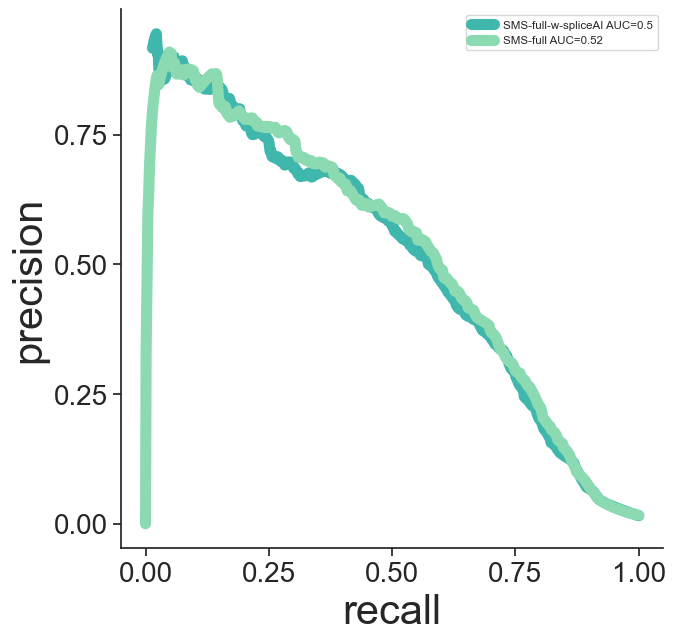

In [137]:
sns.set_style('ticks')
fig, axes = plt.subplots(1, 1, figsize=(7, 7))
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)
pip_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin))
cmap = sns.cubehelix_palette(as_cmap=False, gamma=0.6)

prc=SMS.GLM.run_prc_over_thresholds(test_df_full_w_splice_AI, test_df_full_w_splice_AI.is_causal, test_df_full_w_splice_AI.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC '+str(round(auc_precision_recall,2))
#axes.text(0, 1.1, AUC, fontsize = 22)
axes.set_xlabel('recall', size=40)
axes.set_ylabel('precision', size=40)

ax=sns.lineplot(ax=axes,data=prc, x='recall', y='precision', color=mako_pal[-2],label='SMS-full-w-spliceAI AUC='+str(round(auc_precision_recall,2)) , linewidth=8, alpha=1) 
axes.tick_params(axis='y', labelsize=20 )
axes.tick_params(axis='x', labelsize=20 )

axes.xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes.yaxis.set_major_locator(MaxNLocator(nbins=5))


prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC='+str(round(auc_precision_recall,2))

axes.set_xlabel('recall', size=30)
axes.set_ylabel('precision', size=30)
axes.xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax=sns.lineplot(ax=axes,data=prc, x='recall', y='precision', color=mako_pal[-1],label='SMS-full AUC='+str(round(auc_precision_recall,2)), linewidth=8, alpha=1) 
axes.tick_params(axis='y', labelsize=20 )
axes.tick_params(axis='x', labelsize=20 )
r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))
axes.xaxis.set_major_locator(MaxNLocator(nbins=5))  # max 5 x-ticks
axes.yaxis.set_major_locator(MaxNLocator(nbins=5))

axes.legend(bbox_to_anchor=(1,1), fontsize='x-small')

import other model scores - pangolin, AM, FM
--

In [138]:
import gzip

In [139]:
kavi_dir='/Users/hannahjacobs/MIT Dropbox/Hannah Jacobs/GradSchool/Finucane/follow_on_analyses_NVEs/'

with gzip.open(kavi_dir+"/reviews/reviewer_2/hannah_sqtls_out_3.csv", "rb") as f:
    table = pd.read_csv(f)

cols_w_pangolin=["Pangolin"  in col for col in table.columns ]

table=table.assign(Pangolin_max=table[table.columns[cols_w_pangolin]].max(axis=1))

cols_w_spliceAI=["SpliceAI"  in col for col in table.columns ]

table=table.assign(DS_max=table[table.columns[cols_w_spliceAI]].max(axis=1))






AM_models=[ 'SAM-AM' in test for test in table.columns]

FM_models=[ 'SAM-FM' in test for test in table.columns]

FM_max=table[table.columns[FM_models]].max(axis=1)

AM_max=table[table.columns[AM_models]].max(axis=1)

table=table.assign(FM_max=FM_max)
table=table.assign(AM_max=AM_max)

flare_map=sns.color_palette('flare')


coolwarm=sns.color_palette('coolwarm_r')
mako_pal = sns.color_palette('mako')

main figure: comparison of all major models
--

In [140]:
import sklearn

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


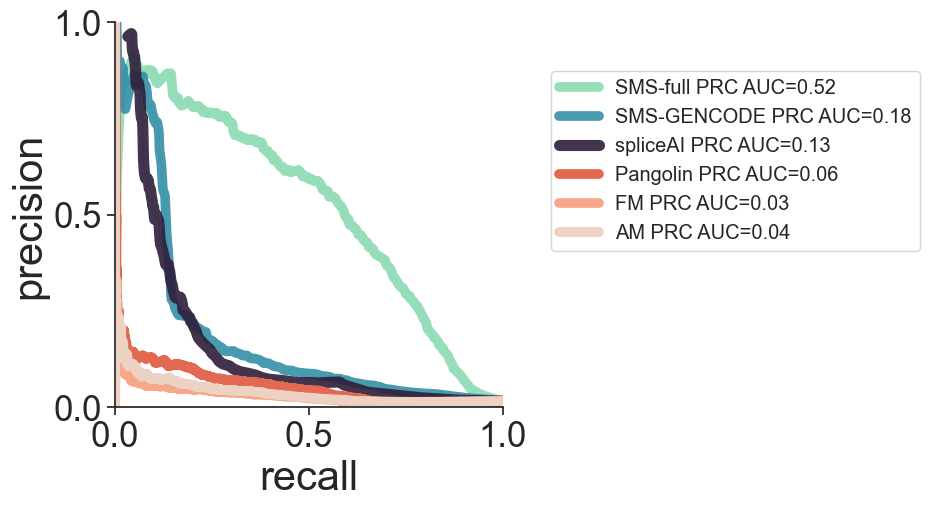

In [148]:
sns.set_style('ticks')
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)



r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))

prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC='+str(round(auc_precision_recall,2))
#axes.text(0, 1.1, AUC, fontsize = 22)
axes.set_xlabel('recall', size=30)
axes.set_ylabel('precision', size=30)

ax=sns.lineplot(ax=axes,data=prc, x='recall', y='precision', color=mako_pal[-1],label='SMS-full PRC AUC='+str(round(auc_precision_recall,2)), linewidth=7, alpha=0.9) 
axes.tick_params(axis='y', labelsize=25 )
axes.tick_params(axis='x', labelsize=25 )
r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))
#axes.text(1, 1.1, r_squared, fontsize = 22)

axes.set_ylim([0,1])
axes.set_xlim([0,1])
#gencode full model
prc=SMS.GLM.run_prc_over_thresholds(test_df_full_but_gencode_dist, test_df_full_but_gencode_dist.is_causal, test_df_full_but_gencode_dist.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC='+str(round(auc_precision_recall,2))
#axes.text(0, 1.5, AUC, fontsize = 22)


ax=sns.lineplot(ax=axes,data=prc, x='recall', y='precision', color=mako_pal[3], linewidth=7, alpha=0.9, label='SMS-GENCODE PRC AUC='+str(round(auc_precision_recall,2))) 

r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))


#splice AI model
prc=SMS.GLM.run_prc_over_thresholds(test_df_spliceAI, test_df_spliceAI.is_causal, test_df_spliceAI.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='splice AI PRC AUC='+str(round(auc_precision_recall,2))
#axes.text(0, 1, AUC, fontsize = 22)


ax=sns.lineplot(ax=axes,data=prc, x='recall', y='precision', color=mako_pal[0], label='spliceAI PRC AUC='+str(round(auc_precision_recall,2)),linewidth=8, alpha=0.9) 


axes.set_xticks([0,0.5,1])
axes.set_yticks([0,0.5,1])


axes.legend(bbox_to_anchor=(0.4,1.1), fontsize='x-small')


test_df_kavi=table
test_df_kavi=test_df_kavi.assign(is_causal=test_df_kavi.pip>0.9)


####other models
for i, other_model in enumerate([ "Pangolin_max",'FM_max','AM_max']):
    for_label = other_model.split('_')[0]
    yp=test_df_kavi[other_model]
    y_target=test_df_kavi.is_causal
    precision, recall, threshold = metrics.precision_recall_curve(y_target, yp)
    roc_auc = sklearn.metrics.auc(recall, precision)
    axes=plt.plot(
        recall,
        precision,
        label=f"{for_label} PRC AUC={roc_auc:.2f}",
        color=coolwarm[i],linewidth=7,
       
    )
    
ax = plt.gca()
plt.legend(bbox_to_anchor=(1.1, 0.9), bbox_transform=ax.transAxes, fontsize='large')



main figure: spliceAI scores vs SMS
--

In [165]:
spliceAI_above_0=model_output_full[model_output_full.DS_MAX>0]


sns.set_context('poster')
plt.rcParams["font.sans-serif"] = 'Arial'

plt.rcParams["font.variant"]='normal'

plt.rcParams["font.size"]='40'

purple=sns.color_palette('Purples')

model_output_spliceAI_for_plot=spliceAI_above_0.assign(variant_to_highlight=spliceAI_above_0.variant_id=='chr1_184702964_G_A_b38')



In [167]:
for_plot = model_output_spliceAI_for_plot[['variant_to_highlight', 'DS_MAX','predicted_prob_being_causal']]

KeyboardInterrupt: 

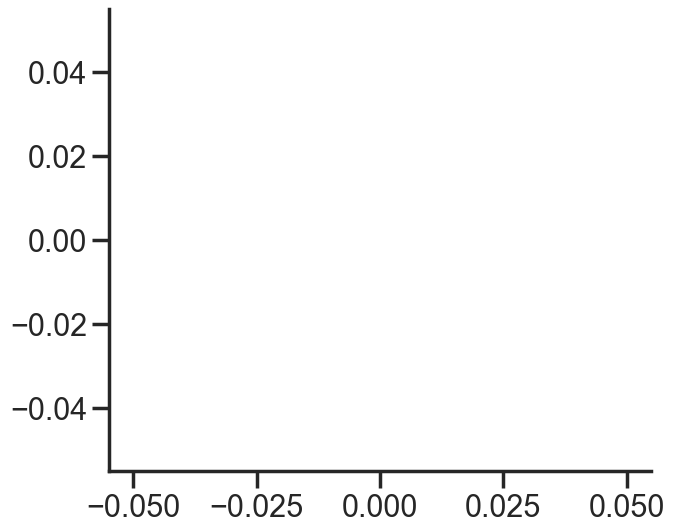

In [172]:
# Assuming spliceAI_above_0 and relevant columns are already defined

fig, axes = plt.subplots(1, 1, figsize=(7, 6))
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)


#axes.legend('',bbox_to_anchor=(1,1.2))
kde = sns.kdeplot(data=for_plot,
            x='DS_MAX',
            y='predicted_prob_being_causal',
            cut=0,
            fill=True,
            levels=10,
            cmap='rocket_r',
            alpha=0.8,cbar=True,
            cbar_kws={'shrink': 0.4, 'aspect': 10, 'label':'density',
                     'ticks': [0,1, 2, 10, 20]},
            ax=axes)


axes.tick_params(axis='y', labelsize=30 )
axes.tick_params(axis='x', labelsize=30 )
axes.set_ylabel('SMS', size=30)
axes.set_xlabel('spliceAI', size=30)
axes.set_xlim([0.1,1])
axes.set_ylim([0,1])
axes.set_yticks([0, 0.1,0.5,1])
axes.set_xticks([0.1, 0.5,1])

plt.show()


/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_12925/602794190.py:8: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=for_plot[::10],


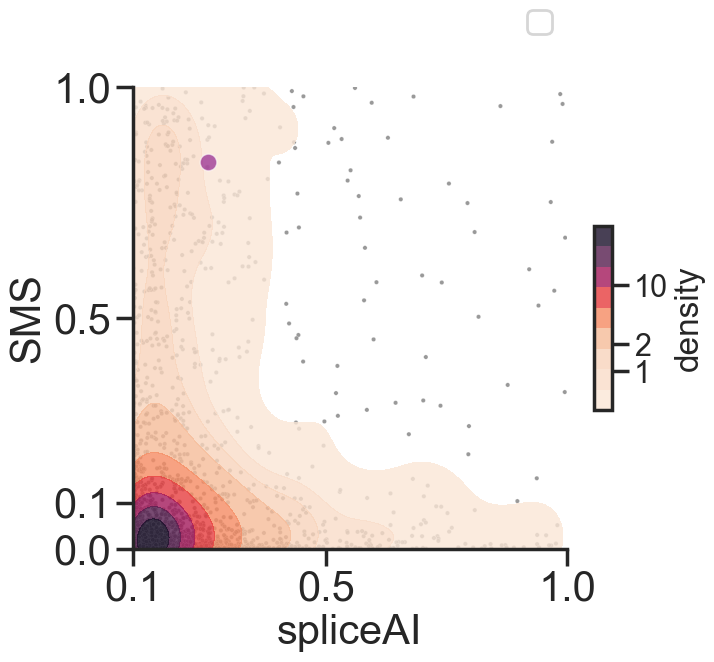

In [196]:


# Assuming spliceAI_above_0 and relevant columns are already defined

fig, axes = plt.subplots(1, 1, figsize=(7, 6))
axes.spines['right'].set_visible(False)
axes.spines['top'].set_visible(False)

# Create a scatter plot with different point sizes
sns.scatterplot(data=for_plot[::10],
                x='DS_MAX',
                y='predicted_prob_being_causal',
                hue='variant_to_highlight',
                size='variant_to_highlight',
                sizes=(10, 5),  # Adjust the range of sizes as needed
                palette=['grey','purple'],
                alpha=0.8,
                ax=axes)




axes.legend('',bbox_to_anchor=(1,1.2))
kde = sns.kdeplot(data=for_plot[::10],
            x='DS_MAX',
            y='predicted_prob_being_causal',
            cut=0,
            fill=True,
            levels=10,
            cmap='rocket_r',
            alpha=0.8,cbar=True,
            cbar_kws={'shrink': 0.4, 'aspect': 10, 'label':'density',
                     'ticks': [0,1, 2, 10, 20]},
            ax=axes)
axes.legend('',bbox_to_anchor=(1,1.2))
# Create a scatter plot with different point sizes
sns.scatterplot(data=for_plot[for_plot.variant_to_highlight],
                x='DS_MAX',
                y='predicted_prob_being_causal',

                sizes=(1000),  # Adjust the range of sizes as needed
                color='purple',
                alpha=0.6,
                ax=axes)

axes.tick_params(axis='y', labelsize=30 )
axes.tick_params(axis='x', labelsize=30 )
axes.set_ylabel('SMS', size=30)
axes.set_xlabel('spliceAI', size=30)
axes.set_xlim([0.1,1])
axes.set_ylim([0,1])
axes.set_yticks([0, 0.1,0.5,1])
axes.set_xticks([0.1, 0.5,1])
axes.legend('',bbox_to_anchor=(1,1.2))
plt.show()


In [26]:
sns.set_context('poster')
plt.rcParams["font.sans-serif"] = 'Arial'

plt.rcParams["font.variant"]='normal'

plt.rcParams["font.size"]='40'

In [27]:
purple=sns.color_palette('Purples')

In [198]:
pwd

'/Users/hannahjacobs/MIT Dropbox/Hannah Jacobs/GradSchool/Finucane/SMS_project/scripts'

In [197]:
puesdo_r_sq_full_model=SMS.GLM.print_puesdo_r(model_fit_full.llf, SMS.GLM.null_model_given_training_set(train_df_full).llf, False, ' of full model')




the puesdo_r_sq is 0.49566949153875384 of full model


In [50]:
variants_affecting_phenotypes_within_5kb.to_csv(data_directory+'variants_affecting_phenotypes_within_5kb.csv')

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)
/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_10250/1940737374.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(ax=axes[1], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3)


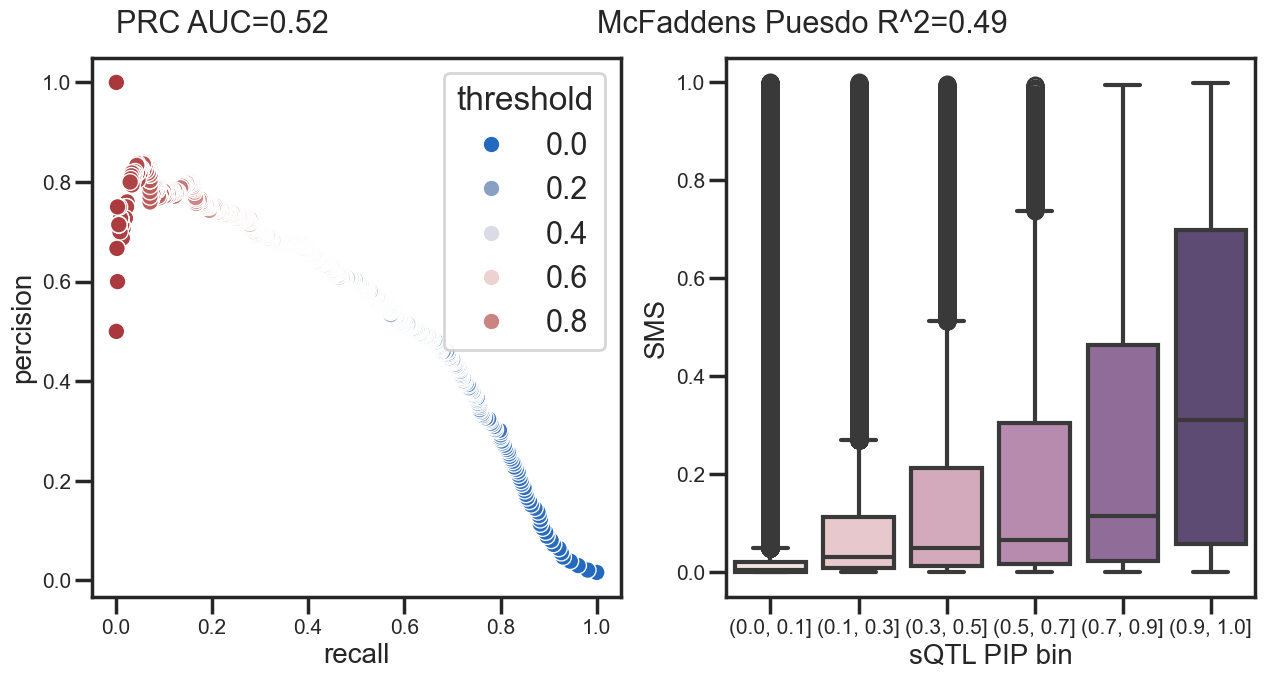

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=False)



pip_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin))
cmap = sns.cubehelix_palette(as_cmap=False, gamma=0.6)

prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC='+str(round(auc_precision_recall,2))
axes[0].text(0, 1.1, AUC, fontsize = 22)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylabel('percision', size=20)

ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', hue="threshold", palette='vlag') 
axes[0].tick_params(axis='y', labelsize=15 )
axes[0].tick_params(axis='x', labelsize=15 )
r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))
axes[0].text(1, 1.1, r_squared, fontsize = 22)

########full model
ax=sns.boxplot(ax=axes[1], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 

axes[1].set_xlabel('sQTL PIP bin', size=20)
axes[1].set_ylabel('SMS', size=20)
axes[1].tick_params(axis='y', labelsize=15 )
axes[1].tick_params(axis='x', labelsize=15 )


fig.savefig(plot_directory+'SMS_full_model_prc_and_boxplot.png')



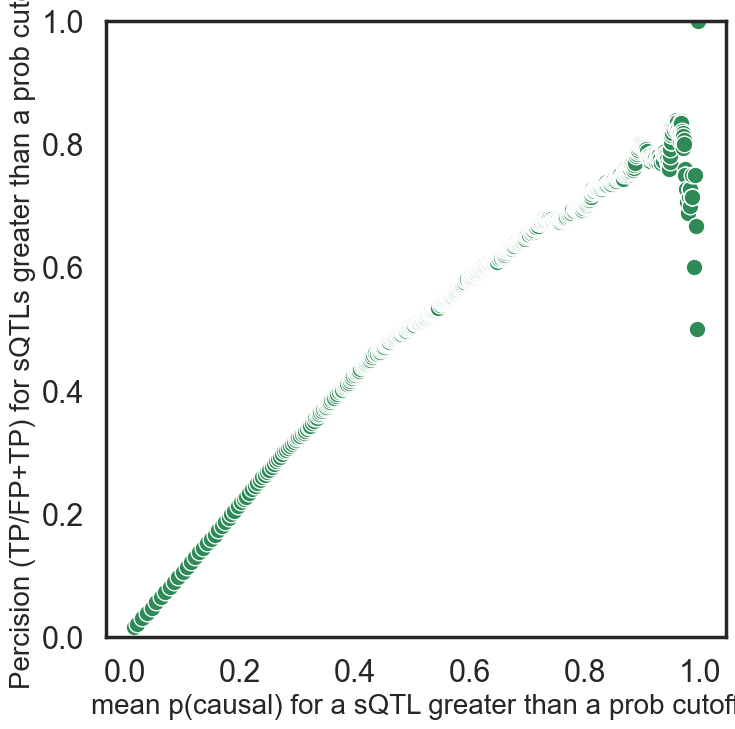

In [179]:
#plot the average prob for everything greater than that threshold

mean_SMS_at_threshold = []

for threshold in prc.threshold:
    
    mean_SMS_at_threshold.append(test_df_full[test_df_full.predicted_prob_being_causal>=threshold].predicted_prob_being_causal.mean())



prc['mean_SMS_at_threshold'] = mean_SMS_at_threshold


sns.set_style("white")

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharey=True)
ax=sns.scatterplot(data=prc, x='mean_SMS_at_threshold', y='precision', color='seagreen')

ax.set_ylabel('Percision (TP/FP+TP) for sQTLs greater than a prob cutoff', size=20)
ax.set_xlabel('mean p(causal) for a sQTL greater than a prob cutoff', size=20)
ax.set_ylim([0,1])
fig.savefig(plot_directory+'SMS_test_set_percision_vs_SMS_score.png')

/opt/anaconda3/envs/running_hail_env/lib/python3.11/site-packages/pandas/core/dtypes/common.py:1645: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


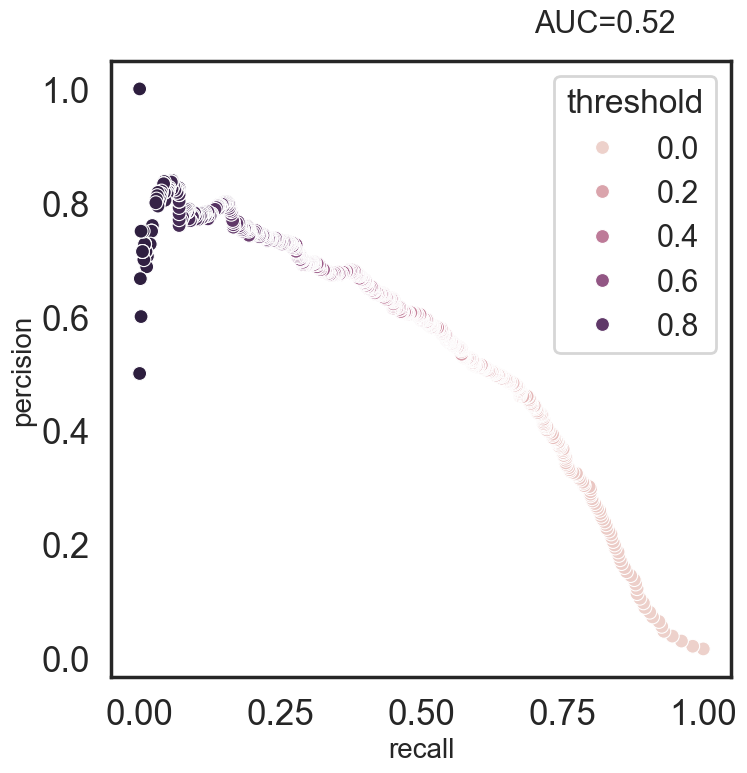

In [180]:

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharey=True)

prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='AUC='+str(round(auc_precision_recall,2))

ax=sns.scatterplot(data=prc, x='recall', y='precision', hue="threshold", s=100)
ax.tick_params(axis='x', labelsize=25 )
ax.tick_params(axis='y', labelsize=25 )

ax.text(0.7, 1.1, AUC, fontsize = 22)
ax.set_xlabel('recall', size=20)
ax.set_ylabel('percision', size=20)

fig.savefig(plot_directory+'PRC full model.png')

In [215]:
model_output_full.to_csv(data_directory+'full_model_results.csv.gz', compression='gzip', index=False)

In [216]:
prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)

model_output_full=SMS.GLM.get_percision_given_prc_curve(model_output_full, prc)

/Users/hannahjacobs/anaconda3/envs/python38env/lib/python3.8/site-packages/pandas/core/dtypes/common.py:1691: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  npdtype = np.dtype(dtype)


There seems to be a great deal of uncertainity surrounding the precision estimate


In [181]:



cred_int_across_thres_upper=[]
cred_int_across_thres_lower=[]

for thres in prc.threshold:
    
    test_df_given_thres=test_df_full[test_df_full.predicted_prob_being_causal>=thres]
    #precision: TP+FP for Precision
    test_df_given_thres.is_causal
    
    
    ci_given_thres=(ci(sum(test_df_given_thres.is_causal), len(test_df_given_thres), alpha=0.05))
    
    cred_int_across_thres_lower.append(ci_given_thres[0])
    cred_int_across_thres_upper.append(ci_given_thres[1])
    

x=prc.threshold
y=prc.precision
fig, ax = plt.subplots()
ax.plot(x,y)
ax.fill_between(x, (cred_int_across_thres_lower), (cred_int_across_thres_upper), color='b', alpha=.1)

ax.set_xlabel('Probability Threshold of SMS')

ax.set_ylabel('Precision')



plt.ylim([0, 1])



NameError: name 'ci' is not defined

(0.0, 1.0)

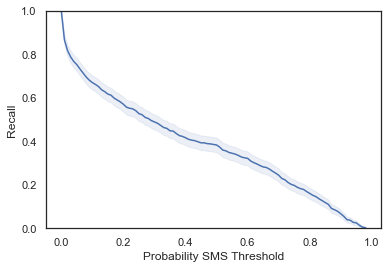

In [80]:



cred_int_across_thres_upper=[]
cred_int_across_thres_lower=[]

for thres in prc.threshold:
    
    test_df_given_thres=test_df_full[test_df_full.predicted_prob_being_causal>=thres]
    #TP+FN for Recall
    recall=sum(test_df_full.is_causal)
    ci_given_thres=(ci(sum(test_df_given_thres.is_causal), recall, alpha=0.05))
    
    cred_int_across_thres_lower.append(ci_given_thres[0])
    cred_int_across_thres_upper.append(ci_given_thres[1])
    

x=prc.threshold
y=prc.recall
fig, ax = plt.subplots()
ax.plot(x,y)
ax.fill_between(x, (cred_int_across_thres_lower), (cred_int_across_thres_upper), color='b', alpha=.1)

ax.set_xlabel('Probability SMS Threshold')

ax.set_ylabel('Recall')


plt.ylim([0, 1])



In [90]:
SMS_df=pd.DataFrame({'score':model_output_full.predicted_prob_being_causal, 'model':'SMS'})

FM_pip=pd.DataFrame({'score':model_output_full.pip, 'model':'FM_pip'})

precision=pd.DataFrame({'score':model_output_full.precision, 'model':'precision'})


for_plot=pd.concat([SMS_df, FM_pip, precision])

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharey=True)
sns.set_style("white")
ax=sns.kdeplot(data=for_plot, x='score', hue='model', palette='Set2', legend=True, linewidth=5)


AttributeError: 'DataFrame' object has no attribute 'precision'

In [51]:
puesdo_r2s=[]

prcs_df=pd.DataFrame([])

auc_precision_recall=[]

ratio_neg_to_pos=[]

puesdo_r_sq_full_model_upsampled=[]
for pip_cutoff in [0.5, 0.7, 0.8, 0.9, 0.95]:
    

    
    [model_fit_full_given_cuttoff, train_fit_full_given_cuttoff, test_fit_full_given_cuttoff, model_df_full_given_cuttoff]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb, pip_cutoff, 0.002, 'default_features', 'w_gtex_distances')
    
    print(model_fit_full_given_cuttoff.llf)
    #predict on same test set
    ypred_test = model_fit_full_given_cuttoff.predict(exog=dict(test_df_full))
    
    test_df_full=test_df_full.assign(predicted_prob_being_causal = ypred_test) 
        
    prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
    
    auc_precision_recall.append(auc(prc.recall, prc.precision))
    
    prc['cutoff']=str(pip_cutoff)
    
    prcs_df=prcs_df.append(prc)

    pos=sum(variants_affecting_phenotypes_within_5kb.pip>=pip_cutoff)
    neg=sum(variants_affecting_phenotypes_within_5kb.pip<=0.002)

    ratio_neg_to_pos.append(neg/pos)
    
    puesdo_r_sq_full_model_upsampled.append(SMS.GLM.print_puesdo_r(model_fit_full_given_cuttoff.llf, SMS.GLM.null_model_given_training_set(train_fit_full_given_cuttoff).llf, False, ' of full model'))
    
    

PatsyError: Error evaluating factor: NameError: name 'not_ss' is not defined
    is_causal ~ in_any_exon*not_ss:(max_5p_maxent + max_5p_maxent * abs_delta_5p_maxent + abs_delta_5p_maxent + max_3p_maxent + max_3p_maxent * abs_delta_3p_maxent + abs_delta_3p_maxent)+ region:(in_oRNAment + in_eCLIP + either_ESE + either_ESS  + DHS_Trynka + H3K27ac_PGC2 + TSS_Hoffman + TFBS_ENCODE + H3K27ac_PGC2 + H3K9ac_Trynka + Promoter_UCSC + H3K4me1_Trynka + H3K4me3_Trynka + Enhancer_Hoffman + Transcribed_Hoffman +gc_twenty_bp +phastcons_100)+ in_any_exon :(log_abs_min_dist_to_a_ss_gtex)
                            ^^^^^^

ValueError: Could not interpret value `recall` for `x`. An entry with this name does not appear in `data`.

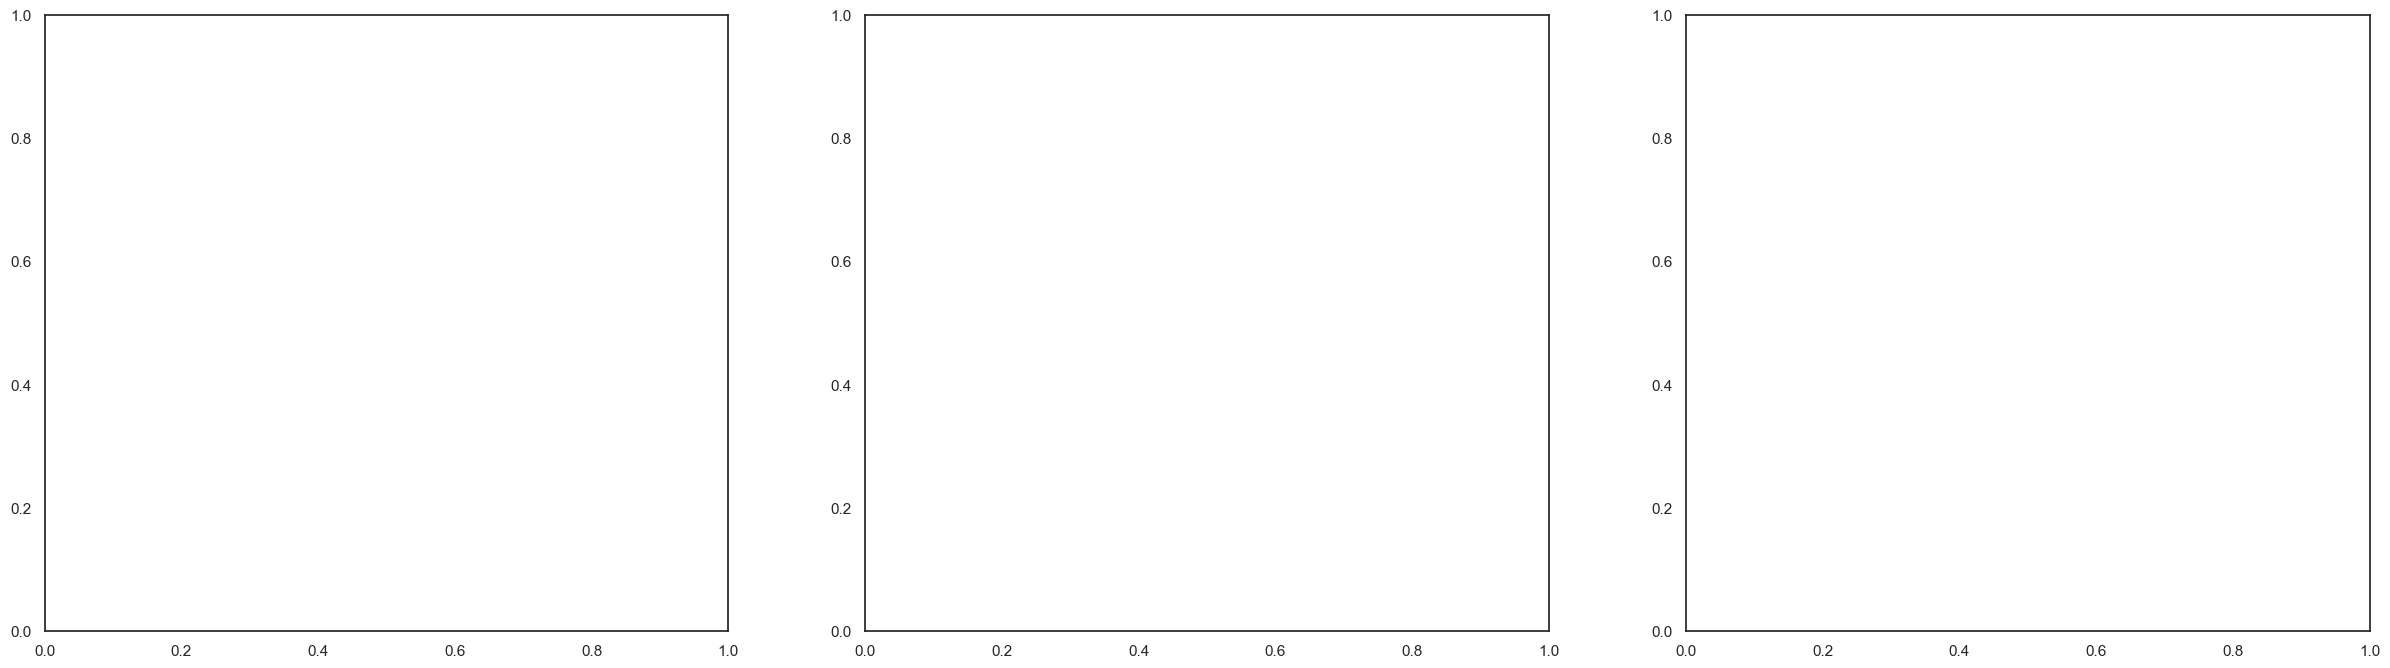

In [52]:
sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=False)


sns.lineplot(ax=axes[0], data=prcs_df, x='recall', y='precision', hue='cutoff', palette='Blues', linewidth=3)

for_plot=pd.DataFrame({'pip_cutoff':[0.5, 0.7, 0.8, 0.9, 0.95], 'ratio_neg_to_pos':ratio_neg_to_pos, 'r2':puesdo_r_sq_full_model_upsampled})

sns.scatterplot(ax=axes[1], data=for_plot, x='pip_cutoff', y='r2', palette='Blues', hue='pip_cutoff', s = 200, edgecolor="black" )

axes[1].set_xlabel('PIP cutoff', size=20)

axes[1].set_ylabel('puesdo R^2 value', size=15)


sns.barplot(ax=axes[2], x="pip_cutoff", y="ratio_neg_to_pos", data=for_plot, palette='Blues')

axes[2].set_ylabel('Fold higher - class is represented over + class', size=15)


In conclusion: this doesnt really change the PRC curve, but does reduce accuracy via puesdo R^2 value.


In [ ]:
from numpy.linalg import inv
[model_fit_full, train_df_full, test_df_full, model_output_full]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb, 0.9, 0.002, 'default_features', 'w_gtex_distances')


In [ ]:
[model_fit_full_given_cuttoff, train_fit_full_given_cuttoff, test_fit_full_given_cuttoff, model_df_full_given_cuttoff]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb, 0.95, 0.002, 'default_features', 'w_gtex_distances')
    

In [ ]:
SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal_ds)
    

In [ ]:

neg_set_pip=0.002
negative_set=variants_affecting_phenotypes_within_5kb[variants_affecting_phenotypes_within_5kb.pip<=neg_set_pip]

positive_set=variants_affecting_phenotypes_within_5kb[variants_affecting_phenotypes_within_5kb.pip>=0.9]

puesdo_r_sq_full_model_downsampled=[]

prcs_df_downsampled=pd.DataFrame([])

auc_precision_recall_downsampled=[]

pip_cutoff=0.9

ratio_neg_to_pos=[]
for frac_to_downsample in [1, 1/2, 1/4, 1/10, 1/20, 1/40]:
    
    new_negative_set=negative_set.sample(frac=frac_to_downsample, replace=False)
    
    for_model=pd.concat([new_negative_set, positive_set])
    
    [model_fit_full_given_cuttoff, train_df_full_given_cutoff, test_df_full_given_cutoff, model_output_full_given_cutoff]=SMS.GLM.run_model(for_model, pip_cutoff, 0.002, 'default_features', 'w_gtex_distances')
    
    #predict on same test set
    ypred_test = model_fit_full_given_cuttoff.predict(test_df_full)
    
    test_df_full=test_df_full.assign(predicted_prob_being_causal = ypred_test) 
        
    prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
    
 
    auc_precision_recall_downsampled.append(auc(prc.recall, prc.precision))
    
    prc['downsample']=str(1 / (frac_to_downsample)) + ' X'
    
    prcs_df_downsampled=prcs_df_downsampled.append(prc)

    pos=sum(model_output_full.pip>=pip_cutoff)
    neg=sum(model_output_full.pip<=0.002)*frac_to_downsample

    ratio_neg_to_pos.append(neg/pos)
    
    puesdo_r_sq_full_model_downsampled.append(SMS.GLM.print_puesdo_r(model_fit_full_given_cuttoff.llf, SMS.GLM.null_model_given_training_set(train_df_full_given_cutoff).llf, False, ' of full model'))
    

In [ ]:

sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=False)

list_downsampled=[str(1/x)+' X' for x in [1, 1/2, 1/4, 1/10, 1/20, 1/40]]

sns.lineplot(ax=axes[0], data=prcs_df_downsampled, x='recall', y='precision', hue='downsample', palette='Blues', linewidth=3)

for_plot=pd.DataFrame({'fraction_downsampled':list_downsampled, 'r2':puesdo_r_sq_full_model_downsampled})


sns.scatterplot(ax=axes[1], data=for_plot, x='fraction_downsampled', y='r2', palette='Blues', hue='fraction_downsampled', s = 200, edgecolor="black" )

axes[1].set_xlabel('fraction downsampled', size=20)

axes[1].set_ylabel('puesdo R^2 value', size=15)

for_plot=for_plot.assign(ratio_neg_to_pos=ratio_neg_to_pos)
sns.barplot(ax=axes[2], x="fraction_downsampled", y="ratio_neg_to_pos", data=for_plot, palette='Blues')

axes[2].set_ylabel('Fraction of - class over + class', size=15)

for_plot['AUC']=auc_precision_recall_downsampled


https://towardsdatascience.com/assumptions-of-logistic-regression-clearly-explained-44d85a22b290

In [369]:



cred_int_across_thres_upper=[]
cred_int_across_thres_lower=[]

for thres in prc.threshold:
    test_df_given_thres=test_df_full[test_df_full.predicted_prob_being_causal>=thres]
    ci_given_thres=(ci(sum(test_df_given_thres.is_causal), len(test_df_given_thres), alpha=0.05))
    cred_int_across_thres_upper.append(ci_given_thres[0])
    cred_int_across_thres_lower.append(ci_given_thres[1])
    

x=prc.threshold
y=prc.precision
fig, ax = plt.subplots()
ax.plot(x,y)
ax.fill_between(x, (y-cred_int_across_thres_lower), (y+cred_int_across_thres_upper), color='b', alpha=.1)

ax.set_xlabel('Prob Threshold')

ax.set_ylabel('Precision+/- uncertainity')

In [36]:
#Training the model using mode of target
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix


from sklearn.linear_model import LogisticRegression

y_test=test_df_full.is_causal

pred_test=test_df_full['predicted_prob_being_causal']

f1_test = f1_score(ypred_test, pred_test)

test_df_full=test_df_full[~test_df_full.predicted_prob_being_causal.isna()]

test_df_full['causal_by_SMS']=test_df_full.predicted_prob_being_causal>=0.9



#y_true: array-like, or label indicator array / sparse matrix
#Ground truth (correct) target values.

#y_pred: array-like, or label indicator array / sparse matrix
#Estimated targets as returned by a classifier.



#Printing f1 and accuracy scores    
print('The accuracy for mode model is:', accuracy_score(y_test, pred_test))
print('The f1 score for the model model is:',f1_score(y_test, pred_test))

#Ploting the cunfusion matrix
conf_matrix(y_test, pred_test)

In [1]:
#add AF

path='/Users/hnjacobs/Documents/MAF_calc_gnomAD/'
file='allele_freq_GTEx.csv'
AF_df = pd.read_csv(path+'allele_freq_GTEx.csv')


AF_df['chromosome'] = 'chr' + AF_df['seqnames'].astype('str') 

AF_df['v_start']=AF_df['start']

#chromosome='chr'+variants_affecting_phenotypes_within_5kb.chromosome.astype('str')

#sqtl_df=sqtl_df.assign(chromosome=chromosome)

variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.merge(AF_df[['chromosome', 'v_start', 'AF']], on=['chromosome'], how='left')       

NameError: name 'pd' is not defined

In [88]:
negative_set_same_gene=negative_set[negative_set.gene_name.isin(positive_set.gene_name)]


new_negative_set=negative_set_same_gene.sample(frac=1, replace=False)
    
for_model=pd.concat([new_negative_set, positive_set])
    
pip_cutoff=0.9
    
[model_fit_full, train_df_full, test_df_full, model_output_full]=SMS.GLM.run_model(for_model, pip_cutoff, 0.002, 'default_features', 'w_gtex_distances')
    
puesdo_r_sq_full_model=SMS.GLM.print_puesdo_r(model_fit_full.llf, SMS.GLM.null_model_given_training_set(train_df_full).llf, False, ' of full model')

    

the puesdo_r_sq is 0.5507854597302655 of full model


Text(0.7, 1.1, 'AUC=0.82')

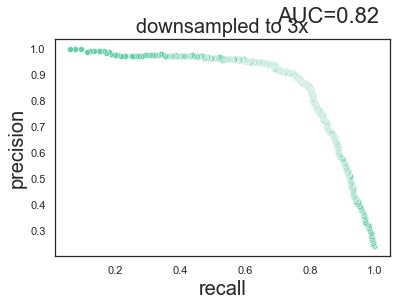

In [177]:
prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)
ax=sns.scatterplot(data=prc, x='recall', y='precision', color=colors[i])
ax.set_xlabel('recall', size=20)
ax.set_ylabel('precision', size=20)
ax.set_title('downsampled to 3x', size=20)
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
ax.text(0.7, 1.1, AUC, fontsize = 22)

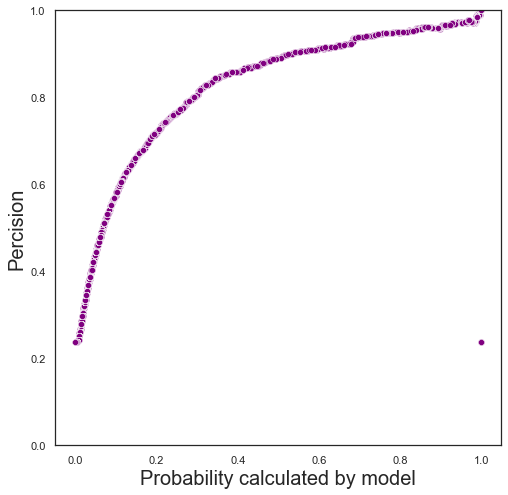

In [181]:
prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
model_output_full=SMS.GLM.get_percision_given_prc_curve(model_output_full, prc)




fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharey=True)
ax=sns.scatterplot(data=model_output_full, x='predicted_prob_being_causal', y='precision', color='purple')

ax.set_ylabel('Percision', size=20)
ax.set_xlabel('Probability calculated by model', size=20)
ax.set_ylim([0,1])
fig.savefig(plot_directory+'SMS_full_model_percision_vs_SMS_score.png')

In [ ]:
test_df_full.predicted_prob_being_causal

In [99]:
features='+ in_oRNAment +in_eCLIP + either_ESE + either_ESS  + DHS_Trynka + + H3K27ac_PGC2 + TSS_Hoffman + TFBS_ENCODE + H3K27ac_PGC2 + H3K9ac_Trynka  + H3K4me1_Trynka + H3K4me3_Trynka + Enhancer_Hoffman + Transcribed_Hoffman +gc_twenty_bp +phastcons_100'
[model_fit_wo_promoter, train_df_wo_promoter, test_df_wo_promoter, model_output_wo_promoter]=SMS.GLM.run_model(variants_affecting_phenotypes_within_5kb, 0.95, 0.002, features, 'w_gtex_distances')


In [100]:
from SMS import plots
from SMS.plots import *

reload(SMS.plots)
from SMS.plots import *

In [101]:
region_number=variants_affecting_phenotypes_within_5kb.annot_info.apply(lambda x: int(x.split('_')[2]))


variants_affecting_phenotypes_within_5kb=variants_affecting_phenotypes_within_5kb.assign(region_number=region_number)






test_without_first_exons = variants_affecting_phenotypes_within_5kb[variants_affecting_phenotypes_within_5kb.region_number>=1]

[model_fit_full_without_first_exons, train_df_full_without_first_exons, test_df_full_without_first_exons, model_output_full_without_first_exons]=SMS.GLM.run_model(test_without_first_exons, 0.95, 0.002, 'default_features', 'w_gtex_distances')


In [23]:

#SMS.GLM.print_puesdo_r(model_fit_wo_promoter.llf, SMS.GLM.null_model_given_training_set(train_df_wo_promoter).llf, False,' not promoters')


/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_10250/911232083.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(ax=axes[0], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3)
/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_10250/911232083.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(ax=axes[1], data=model_output_gtex_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3)
/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykern

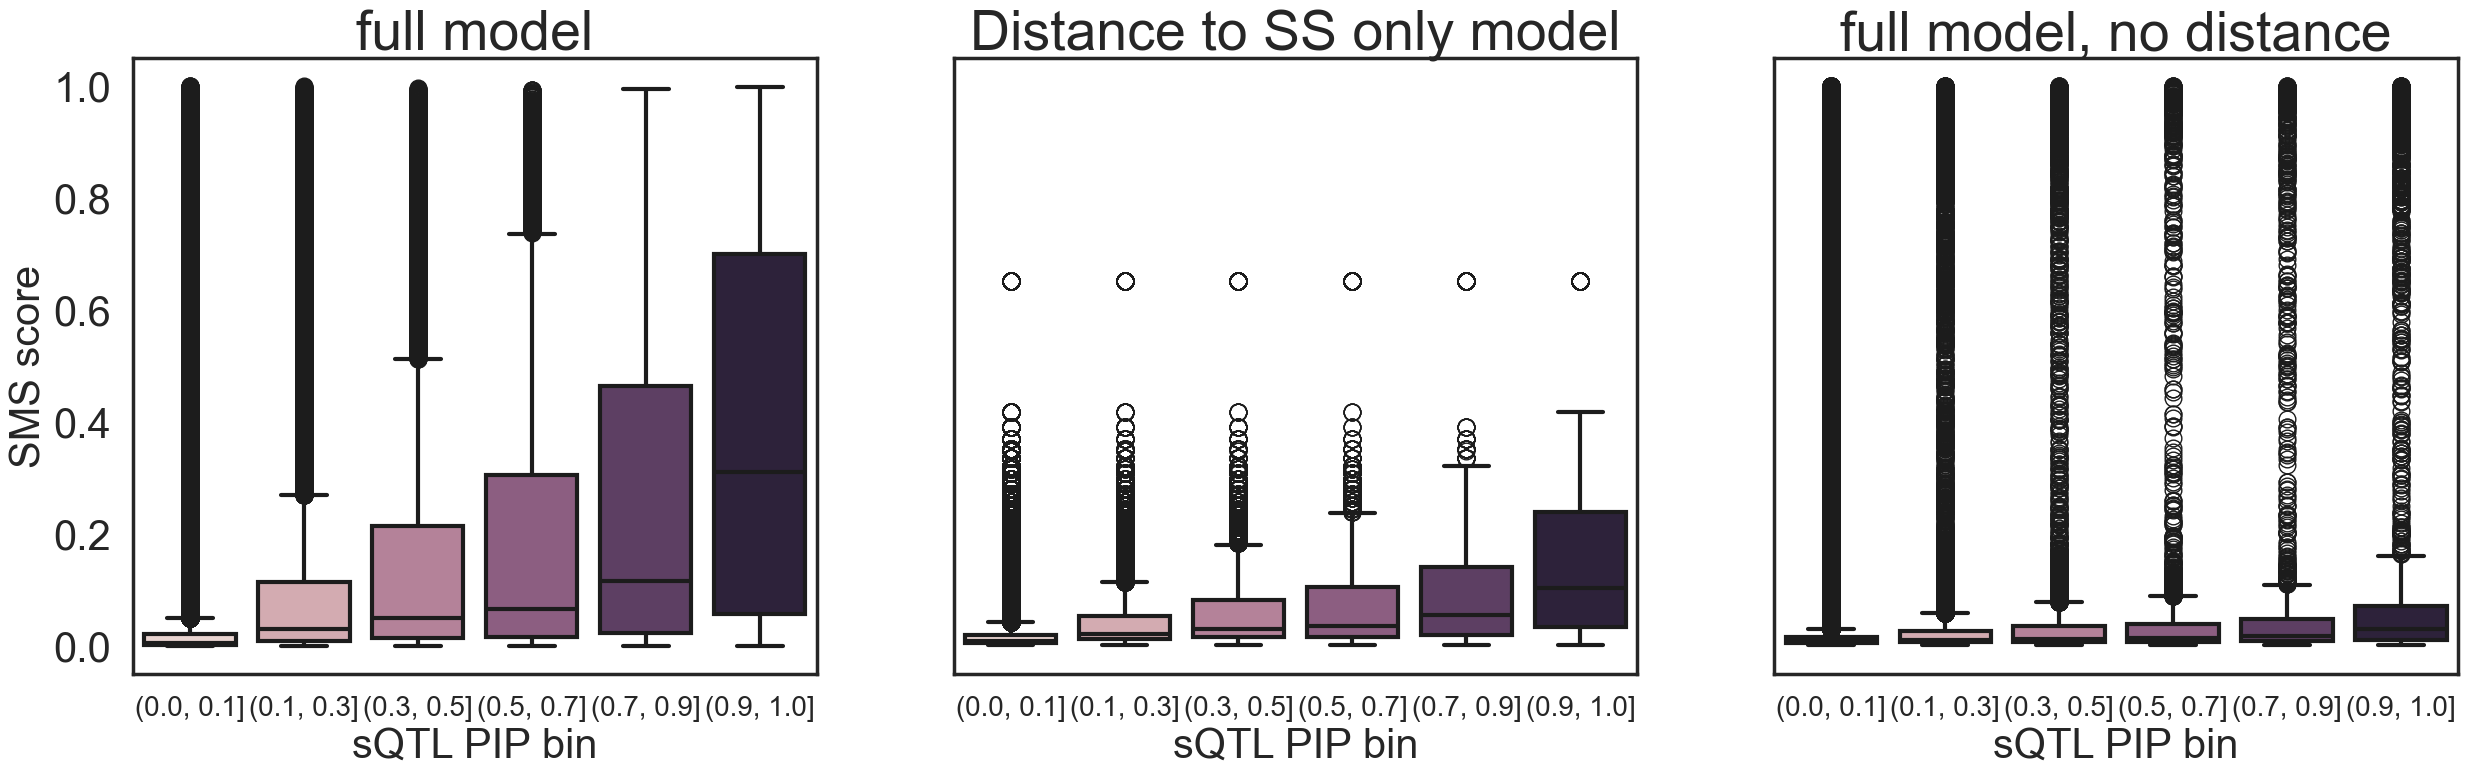

In [182]:
cmap = sns.cubehelix_palette(as_cmap=False)

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

########full model
ax=sns.boxplot(ax=axes[0], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 
axes[0].set_title('full model', size=40)
axes[0].set_xlabel('sQTL PIP bin', size=30)
axes[0].set_ylabel('SMS score', size=30)
axes[0].tick_params(axis='y', labelsize=30 )
axes[0].tick_params(axis='x', labelsize=20 )

########gtex distance
ax=sns.boxplot(ax=axes[1], data=model_output_gtex_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 
axes[1].set_title('Distance to SS only model', size=40)
axes[1].set_xlabel('sQTL PIP bin', size=30)
axes[1].set_ylabel('', size=20)
axes[1].tick_params(axis='y', labelsize=30 )
axes[1].tick_params(axis='x', labelsize=20 )


########no distance, all other features
ax=sns.boxplot(ax=axes[2], data=model_output_no_dists, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 
axes[2].set_title('full model, no distance', size=40)
axes[2].set_xlabel('sQTL PIP bin', size=30)
axes[2].set_ylabel('', size=20)
axes[2].tick_params(axis='y', labelsize=30 )
axes[2].tick_params(axis='x', labelsize=20 )
fig.savefig(plot_directory+'SMS_full_model_gtex_dist_and_no_dist.png')


/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_10250/3870418409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(ax=axes[0,0], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3)
/var/folders/20/mx4zvjpx5_n_bftbxj9cyg0r0000gn/T/ipykernel_10250/3870418409.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(ax=axes[0,1], data=model_output_gtex_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3)


NameError: name 'puesdo_r_sq_gtex_dist' is not defined

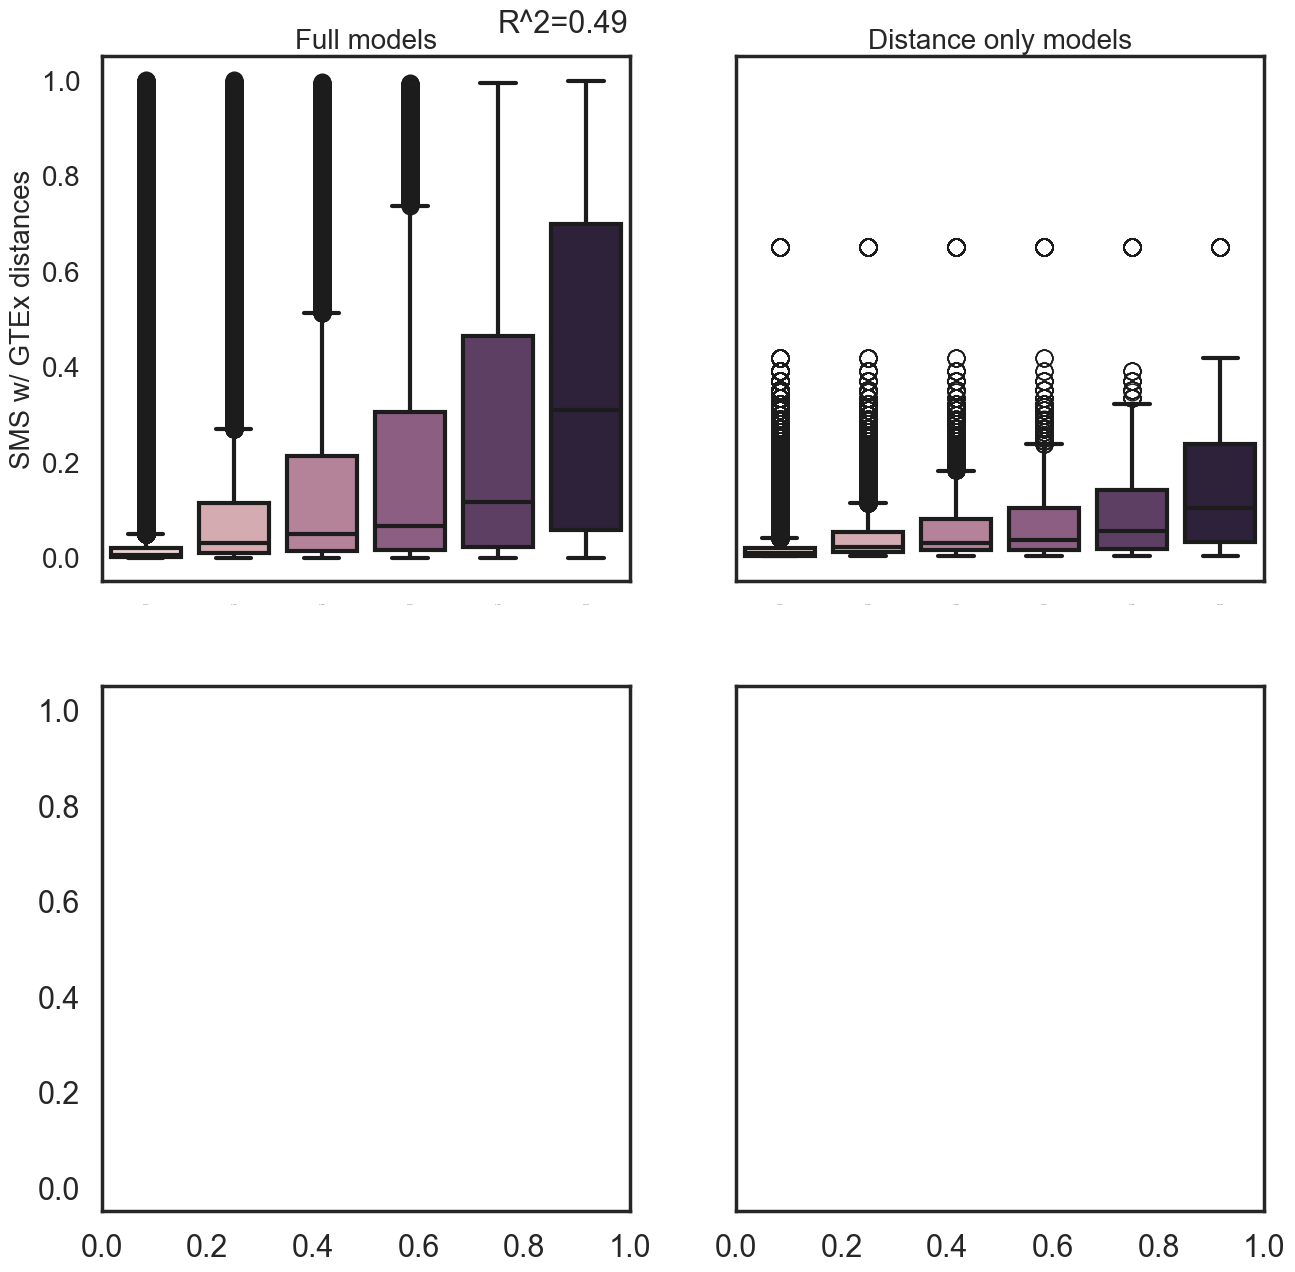

In [183]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15), sharey=True)



pip_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin))
cmap = sns.cubehelix_palette(as_cmap=False)


########full model
ax=sns.boxplot(ax=axes[0,0], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 
axes[0,0].set_title('Full models', size=20)
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('SMS w/ GTEx distances', size=20)
axes[0,0].tick_params(axis='y', labelsize=20 )
axes[0,0].tick_params(axis='x', labelsize=1 )
r_squared='R^2='+str(round(puesdo_r_sq_full_model,2))
axes[0,0].text(4, 1.1, r_squared, fontsize = 22)


########distance to gtex ss
ax=sns.boxplot(ax=axes[0,1], data=model_output_gtex_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 
axes[0,1].set_title('Distance only models', size=20)
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('')
axes[0,1].tick_params(axis='x', labelsize=1 )
r_squared='R^2='+str(round(puesdo_r_sq_gtex_dist,2))
cmap_dist=sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=False)

model_output_gencode_dist

#######full model, gencode only
axes[0,1].text(4, 1.1, r_squared, fontsize = 22)

ax=sns.boxplot(ax=axes[1,0], data=model_output_full_but_gencode_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap_dist, linewidth=3) 

axes[1,0].set_xlabel('sQTL PIP bin', size=20)
axes[1,0].set_ylabel('SMS w/ GENCODE distances', size=20)
axes[1,0].tick_params(axis='x', labelsize=15 )
axes[1,0].tick_params(axis='y', labelsize=20 )
r_squared='R^2='+str(round(puesdo_r_sq_full_gencode,2))
axes[1,0].text(4, 1.1, r_squared, fontsize = 22)

#######distance model, gencode only

ax=sns.boxplot(ax=axes[1,1], data=model_output_gencode_dist, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap_dist, linewidth=3) 

axes[1,1].set_xlabel('sQTL PIP bin', size=20)
axes[1,1].set_ylabel('', size=20)
axes[1,1].tick_params(axis='x', labelsize=15 )
r_squared='R^2='+str(round(puesdo_r_sq_gencode_dist,2))
axes[1,1].text(4, 1.1, r_squared, fontsize = 22)


fig.savefig(plot_directory+'SMS_full_model_gtex_dist_and_no_dist.png')


In [31]:
model_output_full['common_variant']=model_output_full.AF>=0.05
model_output_full['common_variant']=model_output_full['common_variant'].replace(False, 'rare')
model_output_full['common_variant']=model_output_full['common_variant'].replace(True, 'common')

fig,  axes = plt.subplots(1, 1, figsize=(10, 8), sharey=True)
sns.set_theme(style="white")

colors=['lightsteelblue', 'cornflowerblue', 'royalblue', 'mediumblue', 'darkblue', 'navy']
#fig, (ax1, ax2) = plt.subplots(1, 2)

ax1=sns.boxplot(data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette='Greens', linewidth=3, hue='common_variant') 
                          # medianprops=dict(color="white", alpha=0.7))
            #flierprops=dict(markerfacecolor="#707070", marker="d"))



ax1.set_xlabel('PIP bin', size=20)

ax1.set_ylabel('model prediction', size=20)

ax1.legend(loc='upper left')

fig.savefig(plot_dir+'SMS_model_pred_rare_vs_common_variants.png')


AttributeError: 'DataFrame' object has no attribute 'AF'

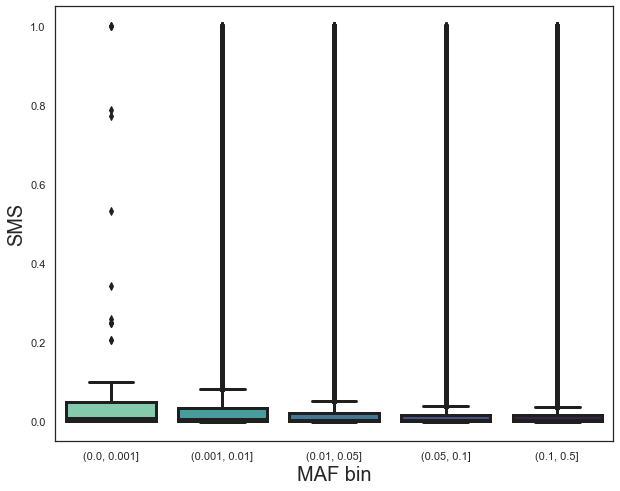

In [198]:
full_model_output['MAF_bin']=pd.cut(full_model_output['AF'], [0, 0.001, 0.01, 0.05, 0.1, 0.5])

fig,  axes = plt.subplots(1, 1, figsize=(10, 8), sharey=True)
sns.set_theme(style="white")

colors=['lightsteelblue', 'cornflowerblue', 'royalblue', 'mediumblue', 'darkblue', 'navy']
#fig, (ax1, ax2) = plt.subplots(1, 2)

ax1=sns.boxplot(data=full_model_output[~full_model_output.AF.isna()], x='MAF_bin', y='predicted_prob_being_causal', palette='mako_r', linewidth=3) 
                          # medianprops=dict(color="white", alpha=0.7))
            #flierprops=dict(markerfacecolor="#707070", marker="d"))



ax1.set_xlabel('MAF bin', size=20)

ax1.set_ylabel('SMS', size=20)


fig.savefig(plot_dir+'SMS_model_across_MAF_bin.png')


Text(0, 0.5, 'SMS using continious distance')

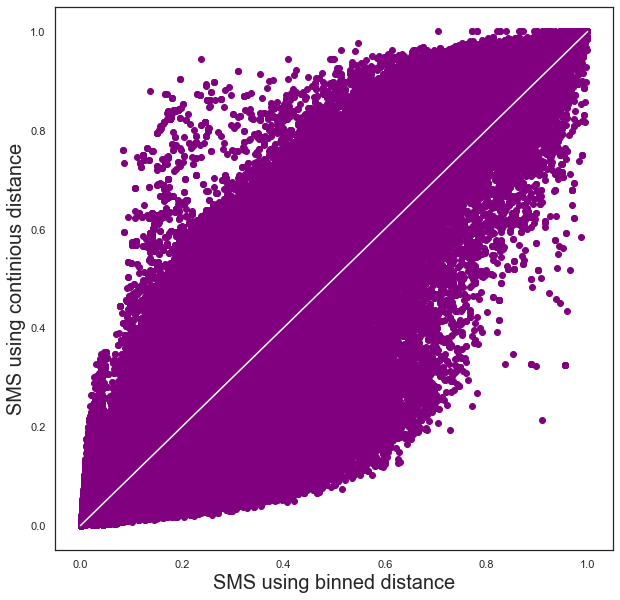

In [147]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)

ax=plt.scatter(model_output_full.predicted_prob_being_causal, model_output_full_cont_dist.predicted_prob_being_causal, color='purple')

plt.plot( [0,1],[0,1], color='w')

plt.xlabel('SMS using binned distance', size=20)

plt.ylabel('SMS using continious distance', size=20)

Text(0.7, 1.1, 'AUC=0.5')

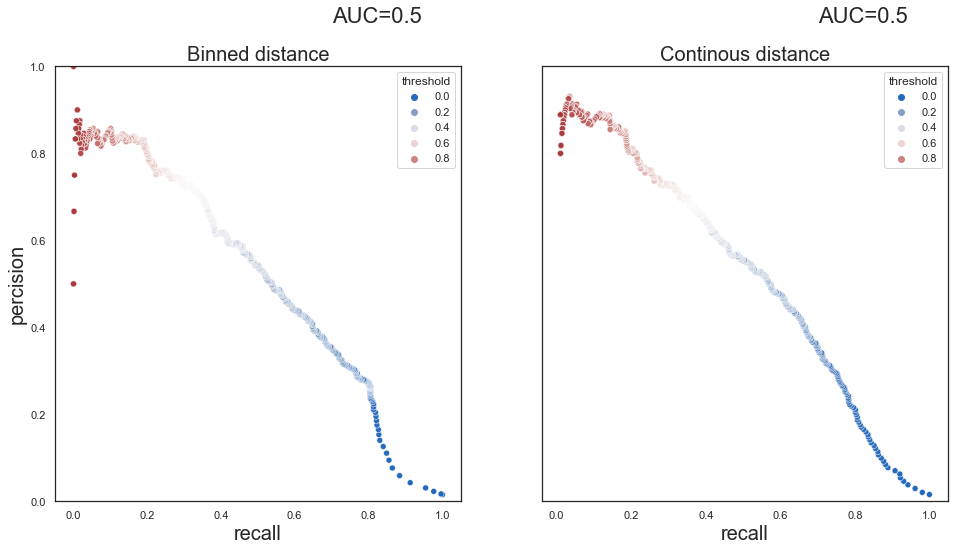

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

###########gencode full model#############
prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)

ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', hue="threshold",palette='vlag') 

axes[0].set_ylabel('percision', size=20)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylim([0,1])
axes[0].set_title('Binned distance', size=20)
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[0].text(0.7, 1.1, AUC, fontsize = 22)

###########gencode full model#############
prc_cont=SMS.GLM.run_prc_over_thresholds(test_df_full_cont_dist, test_df_full_cont_dist.is_causal, test_df_full_cont_dist.predicted_prob_being_causal)

ax=sns.scatterplot(ax=axes[1],data=prc_cont, x='recall', y='precision', hue="threshold",palette='vlag') 

axes[1].set_ylabel('percision', size=20)
axes[1].set_xlabel('recall', size=20)
axes[1].set_ylim([0,1])
axes[1].set_title('Continous distance', size=20)
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[1].text(0.7, 1.1, AUC, fontsize = 22)

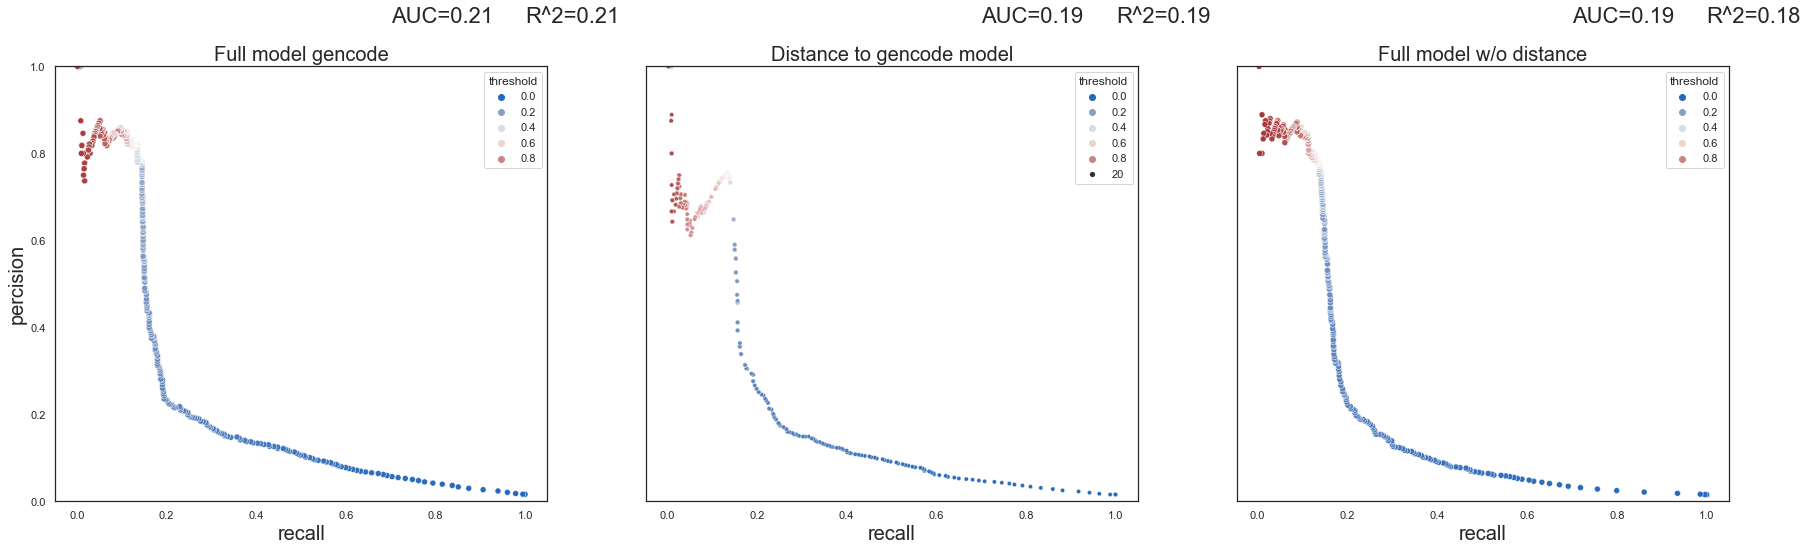

In [52]:


fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

###########gencode full model#############
prc=SMS.GLM.run_prc_over_thresholds(test_df_full_but_gencode_dist, test_df_full_but_gencode_dist.is_causal, test_df_full_but_gencode_dist.predicted_prob_being_causal)

ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', hue="threshold",palette='vlag') 

axes[0].set_ylabel('percision', size=20)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylim([0,1])

auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[0].text(0.7, 1.1, AUC, fontsize = 22)

###########gencode distance#############

prc=SMS.GLM.run_prc_over_thresholds(test_df_gencode_dist, test_df_gencode_dist.is_causal, test_df_gencode_dist.predicted_prob_being_causal)

ax=sns.scatterplot(ax=axes[1],data=prc, x='recall', y='precision', hue="threshold",palette='vlag', size=20)
axes[1].set_xlabel('recall', size=20)

auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[1].text(0.7, 1.1, AUC, fontsize = 22)


###########no distance full model#############


prc=SMS.GLM.run_prc_over_thresholds(test_df_no_dists, test_df_no_dists.is_causal, test_df_no_dists.predicted_prob_being_causal)
ax=sns.scatterplot(ax=axes[2],data=prc, x='recall', y='precision', hue="threshold",palette='vlag')
ax.set_xlabel('recall', size=20)

auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[2].text(0.7, 1.1, AUC, fontsize = 22)


r_squared='R^2='+str(round(puesdo_r_sq_full_gencode,2))
axes[0].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_gencode_dist,2))
axes[1].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_no_dist,2))
axes[2].text(1, 1.1, r_squared, fontsize = 22)


axes[0].set_title('Full model gencode', size=20)
axes[1].set_title('Distance to gencode model', size=20)
axes[2].set_title('Full model w/o distance', size=20)


fig.savefig(plot_directory+'SMS_full_model_gencode_dist_and_no_dist_PRC.png')

In [57]:
prc[prc.precision>=0.8].recall.iloc[0]

0.1222366710013004

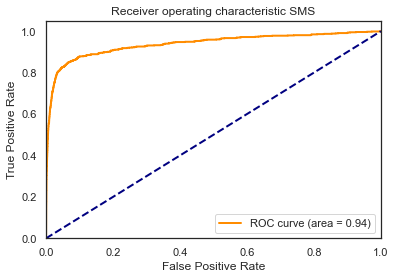

In [83]:
test_df_full=test_df_full[~test_df_full.predicted_prob_being_causal.isna()]

from sklearn import metrics
roc_auc=metrics.roc_auc_score(test_df_full.is_causal, test_df_full.predicted_prob_being_causal)

metrics.roc_curve(test_df_full.is_causal, test_df_full.predicted_prob_being_causal, pos_label=1)



[fpr, tpr, thresholds]=metrics.roc_curve(test_df_full.is_causal, test_df_full.predicted_prob_being_causal, pos_label=1)

plt.figure()
lw = 2
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic SMS")
plt.legend(loc="lower right")
plt.show()

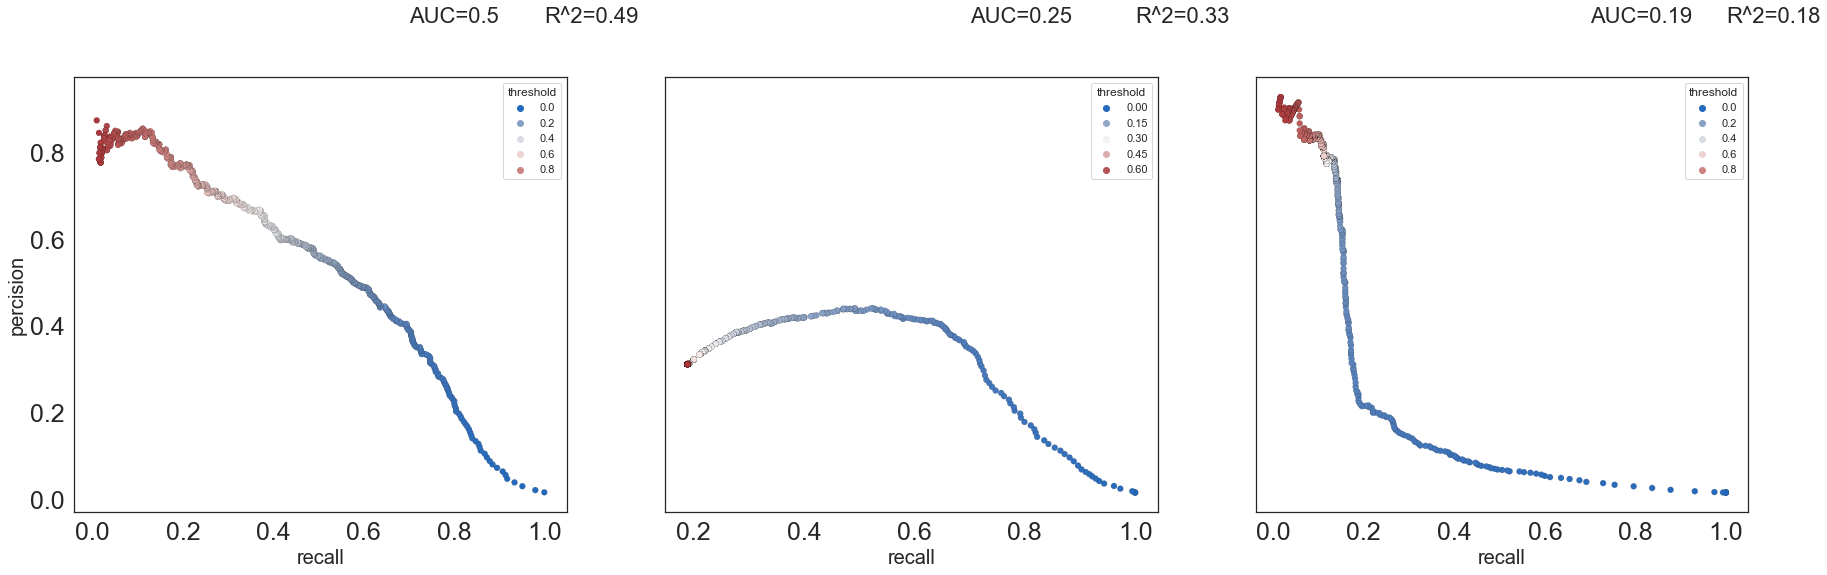

In [35]:

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='AUC='+str(round(auc_precision_recall,2))
axes[0].text(0.7, 1.1, AUC, fontsize = 22)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylabel('percision', size=20)
ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', palette='vlag', hue="threshold", linewidth=0.1, edgecolor='black')
axes[0].tick_params(axis='x', labelsize=25 )
axes[0].tick_params(axis='y', labelsize=25 )

prc=SMS.GLM.run_prc_over_thresholds(test_df_gtex_dist, test_df_gtex_dist.is_causal, test_df_gtex_dist.predicted_prob_being_causal)

auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[1].text(0.7, 1.1, AUC, fontsize = 22)
ax=sns.scatterplot(ax=axes[1],data=prc, x='recall', y='precision', palette='vlag', hue="threshold", linewidth=0.1, edgecolor='black')
axes[1].set_xlabel('recall', size=20)
axes[1].tick_params(axis='x', labelsize=25 )

prc=SMS.GLM.run_prc_over_thresholds(test_df_no_dists, test_df_no_dists.is_causal, test_df_no_dists.predicted_prob_being_causal)
ax=sns.scatterplot(ax=axes[2],data=prc, x='recall', y='precision', palette='vlag', hue="threshold",linewidth=0.1, edgecolor='black')
ax.set_xlabel('recall', size=20)
axes[2].tick_params(axis='x', labelsize=25 )
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[2].text(0.7, 1.1, AUC, fontsize = 22)


r_squared='R^2='+str(round(puesdo_r_sq_full_model,2))
axes[0].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_gtex_dist,2))
axes[1].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_no_dist,2))
axes[2].text(1, 1.1, r_squared, fontsize = 22)


#axes[0].set_title('Full model', size=20)
#axes[1].set_title('Distance to GTEx ss model', size=20)
#axes[2].set_title('Full model w/o GTEx distance', size=20)

fig.savefig(plot_directory+'SMS_full_model_gtex_dist_and_no_dist_PRC.png')

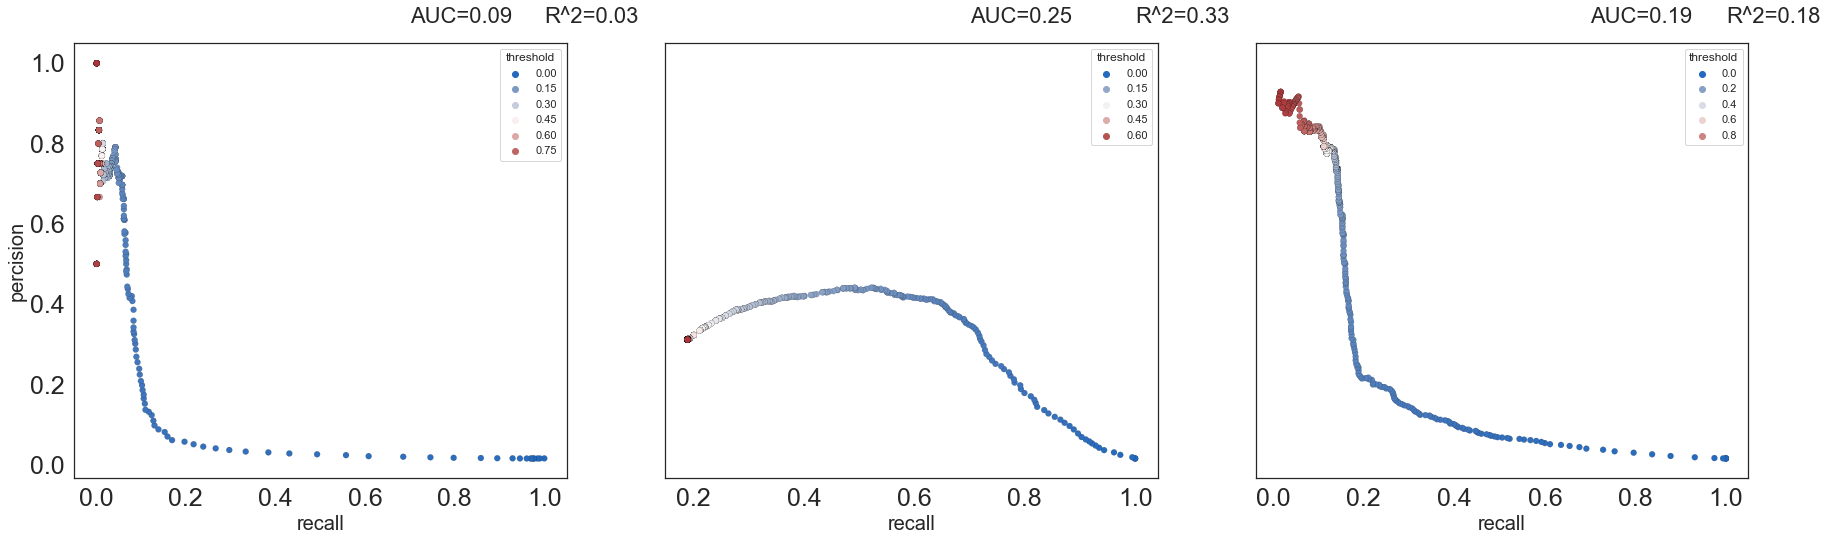

In [36]:

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

prc=SMS.GLM.run_prc_over_thresholds(test_df_maxent, test_df_maxent.is_causal, test_df_maxent.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='AUC='+str(round(auc_precision_recall,2))
axes[0].text(0.7, 1.1, AUC, fontsize = 22)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylabel('percision', size=20)
ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', palette='vlag', hue="threshold", linewidth=0.1, edgecolor='black')
axes[0].tick_params(axis='x', labelsize=25 )
axes[0].tick_params(axis='y', labelsize=25 )

prc=SMS.GLM.run_prc_over_thresholds(test_df_gtex_dist, test_df_gtex_dist.is_causal, test_df_gtex_dist.predicted_prob_being_causal)

auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[1].text(0.7, 1.1, AUC, fontsize = 22)
ax=sns.scatterplot(ax=axes[1],data=prc, x='recall', y='precision', palette='vlag', hue="threshold", linewidth=0.1, edgecolor='black')
axes[1].set_xlabel('recall', size=20)
axes[1].tick_params(axis='x', labelsize=25 )

prc=SMS.GLM.run_prc_over_thresholds(test_df_no_dists, test_df_no_dists.is_causal, test_df_no_dists.predicted_prob_being_causal)
ax=sns.scatterplot(ax=axes[2],data=prc, x='recall', y='precision', palette='vlag', hue="threshold",linewidth=0.1, edgecolor='black')
ax.set_xlabel('recall', size=20)
axes[2].tick_params(axis='x', labelsize=25 )
auc_precision_recall = auc(prc.recall, prc.precision)
AUC='AUC='+str(round(auc_precision_recall,2))
axes[2].text(0.7, 1.1, AUC, fontsize = 22)


r_squared='R^2='+str(round(puesdo_r_sq_maxent,2))
axes[0].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_gtex_dist,2))
axes[1].text(1, 1.1, r_squared, fontsize = 22)

r_squared='R^2='+str(round(puesdo_r_sq_no_dist,2))
axes[2].text(1, 1.1, r_squared, fontsize = 22)


#axes[0].set_title('Full model', size=20)
#axes[1].set_title('Distance to GTEx ss model', size=20)
#axes[2].set_title('Full model w/o GTEx distance', size=20)

fig.savefig(plot_directory+'SMS_full_model_gtex_dist_maxent.png')

Full model PrC and performance on int variants

In [149]:
cmap = sns.cubehelix_palette(as_cmap=False)

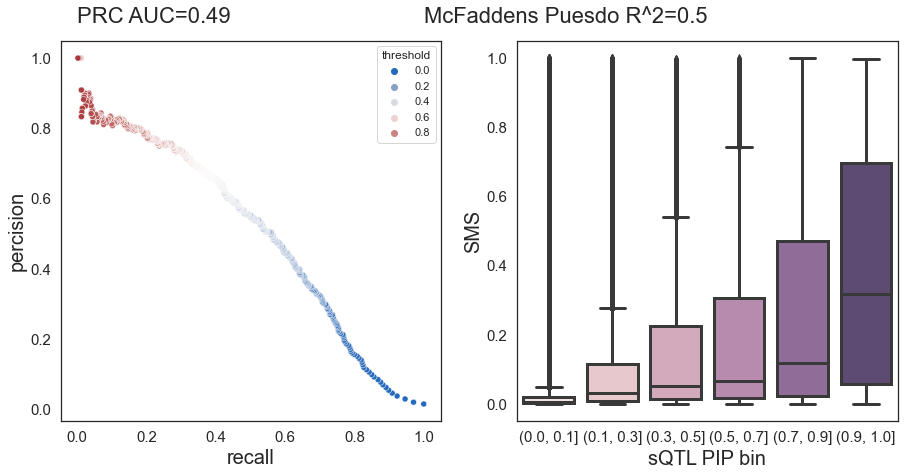

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=False)



pip_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin))
cmap = sns.cubehelix_palette(as_cmap=False, gamma=0.6)

prc=SMS.GLM.run_prc_over_thresholds(test_df_full, test_df_full.is_causal, test_df_full.predicted_prob_being_causal)
auc_precision_recall = auc(prc.recall, prc.precision)

AUC='PRC AUC='+str(round(auc_precision_recall,2))
axes[0].text(0, 1.1, AUC, fontsize = 22)
axes[0].set_xlabel('recall', size=20)
axes[0].set_ylabel('percision', size=20)

ax=sns.scatterplot(ax=axes[0],data=prc, x='recall', y='precision', hue="threshold", palette='vlag') 
axes[0].tick_params(axis='y', labelsize=15 )
axes[0].tick_params(axis='x', labelsize=15 )
r_squared='McFaddens Puesdo R^2='+str(round(puesdo_r_sq_full_model,2))
axes[0].text(1, 1.1, r_squared, fontsize = 22)

########full model
ax=sns.boxplot(ax=axes[1], data=model_output_full, x='sqtl_pip_bin', y='predicted_prob_being_causal', order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)), palette=cmap, linewidth=3) 

axes[1].set_xlabel('sQTL PIP bin', size=20)
axes[1].set_ylabel('SMS', size=20)
axes[1].tick_params(axis='y', labelsize=15 )
axes[1].tick_params(axis='x', labelsize=15 )


fig.savefig(plot_directory+'SMS_full_model_prc_and_boxplot.png')



In [288]:
model_fit_coef=model_fit_full_cont_dist.params.to_frame(name='coef').reset_index()

model_fit_coef['pvalues']=np.array(model_fit_full_cont_dist.pvalues)


In [322]:


model_fit_coef=model_fit_coef[model_fit_coef['index']!='Intercept']

In [347]:


feature = model_fit_coef['index'][9:].apply(lambda x: x.split(':')[1])

region = model_fit_coef['index'][9:].apply(lambda x: x.split(':')[0].split('[')[1].split(']')[0])

In [348]:
model_fit_coef=model_fit_coef.assign(region=region)
model_fit_coef=model_fit_coef.assign(feature=feature)


In [349]:
model_fit_coef['region']=model_fit_coef['region'].replace({'True':'exon', 'False':'intron'})

In [350]:
model_fit_coef[:8]['region']='all'
model_fit_coef[:8]['feature']=model_fit_coef[:8]['index']

/var/folders/km/w07543ln7lbg2h8_nrl0wv880000gn/T/ipykernel_3104/1226247332.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_fit_coef[:8]['region']='all'
/var/folders/km/w07543ln7lbg2h8_nrl0wv880000gn/T/ipykernel_3104/1226247332.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_fit_coef[:8]['feature']=model_fit_coef[:8]['index']


In [367]:
sig=model_fit_coef[model_fit_coef.pvalues>=0.01]

In [368]:
coef_heatmap=pd.pivot(sig, index='feature', columns='region', values='coef')

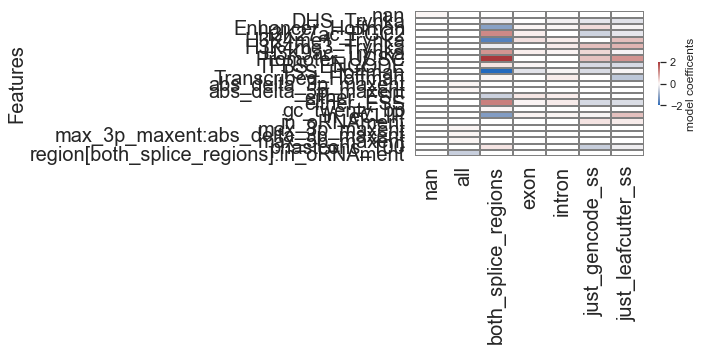

In [374]:



fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharey=True)
    
ax=sns.heatmap(coef_heatmap, annot=False, cmap='vlag', center=0, vmax=2, vmin=-2, linewidth=2, linecolor='grey', cbar_kws={"shrink":0.3, 'label': 'model coefficents', 'location':'right'})
ax.set_ylabel('Features', size=20)
#ax.set_xlabel('Region', size=20)
ax.set_xlabel('', size=20)
plt.yticks( size=20)
plt.xticks(rotation = 90, size=20)

#labels = ['any','exon', 'intron', 'annotated ss', 'GTEx ss']

#ax.set_xticklabels(labels, rotation=90)
plt.tight_layout()
fig.savefig(plot_directory+'significant_coef_in_full_model.png',dpi=300, bbox_inches = "tight")



In [254]:



model_fit_coef=model_fit_full.params.to_frame(name='coef').reset_index()

model_fit_coef['pvalues']=np.array(model_fit_full.pvalues)

sig_Pvals=list(model_fit_full.pvalues<=0.05)

model_fit_coef=model_fit_coef[sig_Pvals]



model_fit_coef=model_fit_coef[model_fit_coef['index']!='Intercept']




model_fit_coef['index'].iloc[-1]='region[intron]:log_abs_min_dist_to_a_ss_gtex'
model_fit_coef['index'].iloc[-2]='region[exon]:log_abs_min_dist_to_a_ss_gtex'

model_fit_coef['index'].iloc[0]='region[all]:max_5p_maxent:abs_delta_5p_maxent'



feature = model_fit_coef['index'].apply(lambda x: x.split(':')[1])

region = model_fit_coef['index'].apply(lambda x: x.split(':')[0].split('[')[1].split(']')[0])

model_fit_coef=model_fit_coef.assign(region=region)
model_fit_coef=model_fit_coef.assign(feature=feature)

model_fit_coef=model_fit_coef.replace({'max_5p_maxent': '5 prime ss score', 'either_ESE': 'ESE',
                       'either_ESS':'ESS', 'DHS_Trynka':'DHS peak', 'H3K27ac_PGC2':'H3K27ac mark'
                       ,'TSS_Hoffman': 'TSS', 'TFBS_ENCODE': 'TF binding site',
                       'Promoter_UCSC': 'Promoter', 'H3K4me1_Trynka':'H3K4me1 mark',
                       'H3K4me3_Trynka': 'H3K4me3 mark', 'gc_twenty_bp': 'GC content', 'Transcribed_Hoffman':'Transcribed Region', 
                       'phastcons_100': 'conservation', 'log_abs_min_dist_to_a_ss_gtex': 'Distance to nearest ss', 
                                      'in_oRNAment':'RBP binding site'})

#model_fit_coef.index= model_fit_coef['feature']
model_fit_coef=model_fit_coef[model_fit_coef.region!='both_splice_regions']
coef_heatmap=pd.pivot(model_fit_coef, index='feature', columns='region', values='coef')




fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
    
ax=sns.heatmap(coef_heatmap, annot=True, annot_kws={"size": 18}, cmap='vlag', center=0, vmax=2, vmin=-2, linewidth=2, linecolor='grey', cbar_kws={"shrink":0.3, 'label': 'model coefficents', 'location':'right'})
ax.set_ylabel('Features', size=20)
#ax.set_xlabel('Region', size=20)
ax.set_xlabel('', size=20)
plt.yticks( size=20)
plt.xticks(rotation = 90, size=20)

labels = ['any','exon', 'intron', 'annotated ss', 'GTEx ss']

ax.set_xticklabels(labels, rotation=90)
plt.tight_layout()
fig.savefig(plot_directory+'significant_coef_in_full_model.png',dpi=300, bbox_inches = "tight")



/Users/hnjacobs/miniconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


IndexError: list index out of range

In [60]:
from upsetplot import generate_counts

example = generate_counts()

def upset_plot(df, annots, P_cutoff):
    import upsetplot
    from upsetplot import plot
    from matplotlib import pyplot
    
    df=df[df.precision>P_cutoff]
    
    #fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharey=True)
    
    subset=df.groupby(annots).size()

    ax=plot(subset, facecolor="purple")  
    
    
    pyplot.show()
    
    
    #fig.savefig(plot_dir+'intersection_of_in_splice_region_leafcutter_and_gencode.png')






In [61]:
#model_output_full['precision']. nlargest(n=round(len(model_output_full)*0.01))

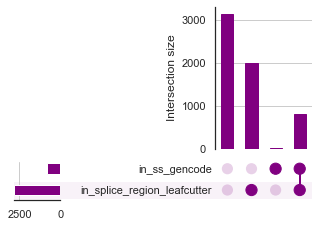

In [68]:

upset_plot(model_output_full,['in_splice_region_leafcutter','in_ss_gencode'], 0.8)



<AxesSubplot:xlabel='LOEUF', ylabel='Proportion'>

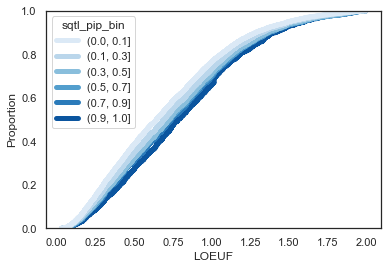

In [421]:
sns.ecdfplot(data=model_output_full, x='LOEUF', hue='sqtl_pip_bin', palette='Blues',
            linewidth=5,
            hue_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)))

In [423]:

model_output_full['SMS_bin']=pd.cut(model_output_full.predicted_prob_being_causal, bins=[0, .1, .3, .6, .8, 0.9, 1])


In [439]:
model_output_full=model_output_full[~model_output_full.predicted_prob_being_causal.isna()]

<AxesSubplot:xlabel='LOEUF', ylabel='Proportion'>

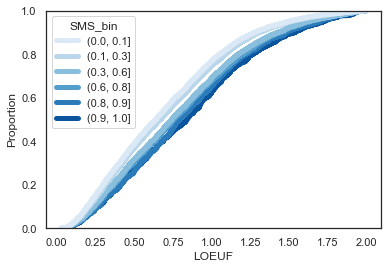

In [441]:
sns.ecdfplot(data=model_output_full, x='LOEUF', hue='SMS_bin', palette='Blues',
            linewidth=5,
            hue_order=sorted(set(model_output_full.SMS_bin)))

<AxesSubplot:xlabel='LOEUF', ylabel='Proportion'>

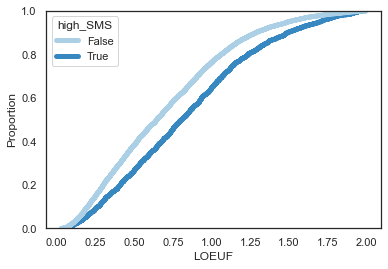

In [452]:
for_plot=model_output_full
for_plot=for_plot.assign(high_SMS=for_plot.predicted_prob_being_causal>=0.8)

sns.ecdfplot(data=model_output_full, x='LOEUF', hue='high_SMS', palette='Blues',
            linewidth=5)

<AxesSubplot:xlabel='LOEUF', ylabel='Proportion'>

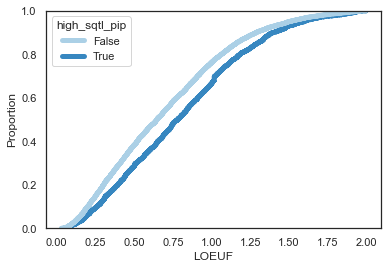

In [461]:
for_plot=model_output_full
for_plot=for_plot.assign(high_sqtl_pip=for_plot.pip>=0.8)

sns.ecdfplot(data=for_plot, x='LOEUF', hue='high_sqtl_pip', palette='Blues',
            linewidth=5)

In [ ]:
sns.ecdfplot(data=model_output_full, x='LOEUF', hue='sqtl_pip_bin', palette='Blues',
            linewidth=5,
            hue_order=sorted(set(variants_affecting_phenotypes_within_5kb.sqtl_pip_bin)))

In [83]:
just_5p_ss_lc = (model_output_full.just_leafcutter_ss) & (model_output_full.in_5p_ss_leafcutter)

just_5p_ss_gencode = (model_output_full.just_gencode_ss) & (model_output_full.in_5p_ss_gencode)


model_output_full=model_output_full.assign(just_5p_ss_lc=just_5p_ss_lc)

model_output_full=model_output_full.assign(just_5p_ss_gencode=just_5p_ss_gencode)


In [91]:
model_output_full[model_output_full.just_5p_ss_lc].max_5p_maxent.median()

8.095746149492186

In [92]:
model_output_full[model_output_full.just_5p_ss_gencode].max_5p_maxent.median()

7.356302617018701

Text(0.5, 1.0, '3 prime ss scores')

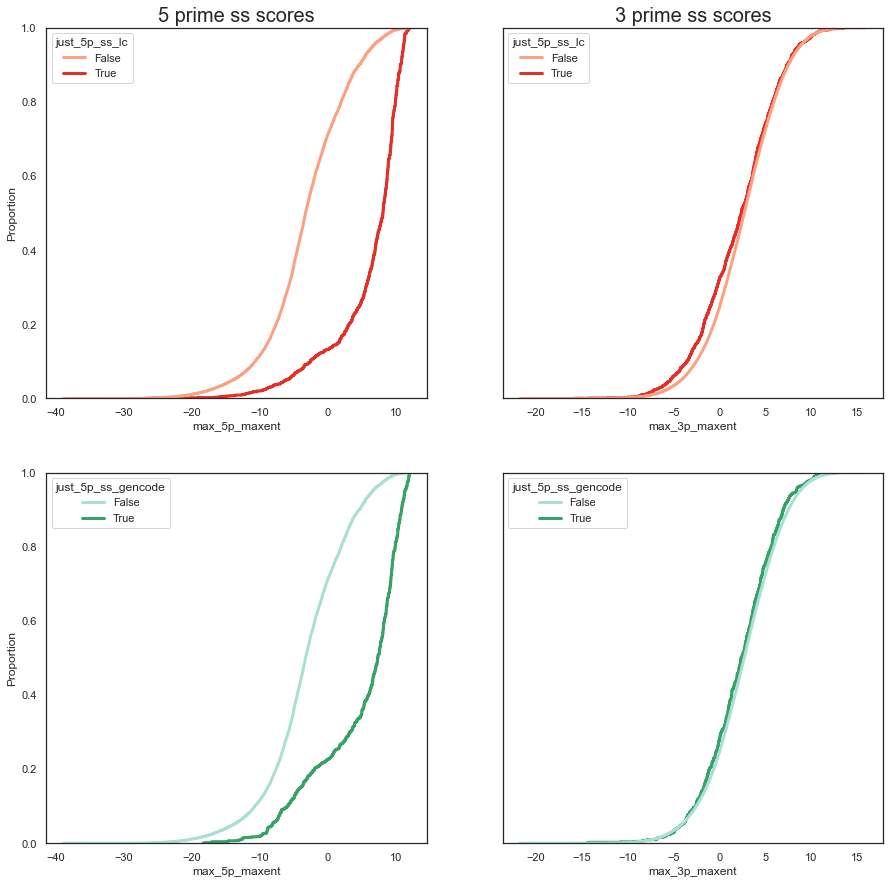

In [84]:

fig, axes = plt.subplots(2, 2, figsize=(15, 15), sharey=True)


ax=sns.ecdfplot(ax=axes[0,0], data=model_output_full, x='max_5p_maxent', hue='just_5p_ss_lc', palette='Reds', linewidth=3)

ax=sns.ecdfplot(ax=axes[1,0],data=model_output_full, x='max_5p_maxent', hue='just_5p_ss_gencode', palette='BuGn', linewidth=3)

axes[0,0].set_title('5 prime ss scores', size=20)

ax=sns.ecdfplot(ax=axes[0,1], data=model_output_full, x='max_3p_maxent', hue='just_5p_ss_lc', palette='Reds', linewidth=3)

ax=sns.ecdfplot(ax=axes[1,1],data=model_output_full, x='max_3p_maxent', hue='just_5p_ss_gencode', palette='BuGn', linewidth=3)

axes[0,1].set_title('3 prime ss scores', size=20)

Sens vs spec

https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/

Thoughts
--
The best predictors of a variant being causal for a sQTL is being a in a splice site, but importantly, these splice sites are those that is present in the leafcutter phenotypes. 

In general, the categorical variables have lower coef for being causal for a sQTL.

This makes sense though because each individual nt (in the case of dist to ss) or each bit of a maxent score is not very predictive of sQTL PIP. But I would like to see if we can represent the data in a way that is better for sQTL phenotypes

This makes sense though because it is harder to model this data. 


Export data
--